# Causal Forecasting Pipeline
## Мульти-активный каузальный прогноз: 10 финансовых рядов

**Структура пайплайна:**
| Шаг | Модуль | Описание |
|-----|--------|----------|
| 1 | DAG Definitions | Экспертные DAG + backdoor criterion |
| 2 | Variable Selection | LassoCV / Expert DAG / PCMCI+ |
| 3 | Causal Models | SCM-DoWhy, DML, VAR+Granger, IV-2SLS |
| 4 | Baseline Models | ARIMA, Prophet, Random Forest, LSTM |
| 5 | Comparison Report | Сравнение метрик, визуализация |

**Активы:** WTI Oil · Nat.Gas · Gold · EUR/USD · GBP/USD · USD/JPY · CPI · IndProd · UMCSENT · Bitcoin · Ethereum

---
### Подготовка: загрузка данных
Положите CSV-файлы в папку `datasets/` рядом с этим ноутбуком. Структура:
```
datasets/
  A_WTI_oil.csv
  A_NatGas.csv
  A_Gold.csv
  B_EURUSD.csv
  B_GBPUSD.csv
  B_USDJPY.csv
  C_CPI.csv
  C_IndProd.csv
  C_UMCSENT.csv
  D_BTC.csv
  D_ETH.csv
```
Каждый CSV: индекс = дата (DatetimeIndex), столбцы = числовые переменные, целевой ряд — по имени из таблицы выше.

> **Если файл не найден** — пайплайн автоматически генерирует синтетические данные и продолжает работу.


## ⚙️ 0. Установка зависимостей и импорты

In [8]:
# Базовые зависимости (обычно уже есть)
# %pip install -q scikit-learn statsmodels pmdarima

# Каузальные библиотеки (опционально — есть fallback)
# %pip install -q tigramite econml dowhy

# Baseline модели (опционально)
# %pip install -q prophet pmdarima

import warnings
warnings.filterwarnings("ignore")

import logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s │ %(levelname)-7s │ %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)

from pathlib import Path

# Директории
DATASETS_DIR = Path("datasets")
RESULTS_DIR  = Path("results")
FIGURES_DIR  = Path("figures")

for d in [DATASETS_DIR, RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(exist_ok=True)

print("✓ Директории созданы:", [str(d) for d in [DATASETS_DIR, RESULTS_DIR, FIGURES_DIR]])
print("✓ Доступные датасеты:", sorted([f.name for f in DATASETS_DIR.glob("*.csv")]))

✓ Директории созданы: ['datasets', 'results', 'figures']
✓ Доступные датасеты: ['A_Gold.csv', 'A_NatGas.csv', 'A_WTI_oil.csv', 'B_EURUSD.csv', 'B_GBPUSD.csv', 'B_USDJPY.csv', 'C_CPI.csv', 'C_IndProd.csv', 'C_UMCSENT.csv', 'D_BTC.csv', 'D_ETH.csv']


---
## 📐 Шаг 1: Экспертные DAG + Backdoor Criterion

Определяем каузальные структуры для каждого из 11 активов:
- **causes** — прямые причины X
- **confounders** — конфаундеры Z (открывают backdoor-пути)
- **mediators** — медиаторы (не контролируем — over-control bias)
- **instruments** — инструментальные переменные (для IV/DML)


In [9]:
from dataclasses import dataclass, field
from typing import List, Dict, Optional


@dataclass
class AssetDAG:
    """Хранит экспертный DAG и наборы переменных для одного целевого ряда."""
    name: str
    target: str
    group: str          # A / B / C / D
    freq: str           # 'D' = daily, 'ME' = monthly
    file: str           # имя CSV из datasets/

    causes: List[str] = field(default_factory=list)
    confounders: List[str] = field(default_factory=list)
    mediators: List[str] = field(default_factory=list)
    instruments: List[str] = field(default_factory=list)
    backdoor_paths: List[str] = field(default_factory=list)

In [10]:
# ── ГРУППА A: Энергетика и Металлы ───────────────────────────────────────────

WTI_DAG = AssetDAG(
    name="WTI Crude Oil",
    target="WTI_oil",
    group="A",
    freq="D",
    file="A_WTI_oil.csv",
    
    # ===== Прямые причины (causes) =====
    causes=[
        "Cushing_stocks",        # центральный физический узел (запасы в Кушинге)
        "Brent",                 # глобальный бенчмарк
        "DXY",                   # индекс доллара
        "IndProd_USA",           # промышленное производство США (прямой спрос)
        "US_oil_prod_w",         # добыча в США (предложение)
        "WTI_Brent_spread",      # арбитражный сигнал (экспортная рентабельность)
    ],
    
    # ===== Конфаундеры (общие причины для нескольких переменных) =====
    confounders=[
        "VIX",                   # рыночный страх (влияет и на SP500, и на ликвидность нефти)
        "SP500",                 # аппетит к риску (через риск-премию в DXY и нефти)
        "Yield10Y",              # доходность 10Y (альтернативные издержки + DXY)
        "InflationCPI",          # инфляция (влияет на Yield10Y и политику ФРС)
        "Copper",                # "Доктор Медь" (опережающий индикатор мирового спроса)
        "Silver",                # промышленный + монетарный сигнал (дублирует Copper и DXY)
    ],
    
    # ===== Медиаторы (передаточные переменные) =====
    mediators=[
        "WTI_Brent_spread",      # Brent → спред → WTI (канал арбитража)
        "EIA_crude_total",       # общие запасы → запасы в Кушинге → WTI (каскад)
    ],
    
    # ===== Инструменты (экзогенные переменные, не коррелирующие с ошибкой) =====
    instruments=[
        "US_oil_prod_w",         # добыча (экзогенна в краткосрочном периоде)
    ],
    
    # ===== Запрещённые/контролируемые обратные пути (backdoor paths) =====
    backdoor_paths=[
        "VIX → SP500 → DXY → WTI_oil",
        "Yield10Y → DXY → WTI_oil",
        "InflationCPI → Yield10Y → DXY → WTI_oil",
        "Copper → Brent → WTI_oil",
        "Silver → DXY → WTI_oil",
        "IndProd_USA → Cushing_stocks → WTI_oil",
    ],
)

NATGAS_DAG = AssetDAG(
    name="Natural Gas (Henry Hub)", target="NatGas", group="A", freq="D", file="A_NatGas.csv",
    causes=["EIA_gas_stocks", "WTI_oil", "Copper", "ISM_PMI"],
    confounders=["VIX", "SP500", "DXY", "IndProd_USA"],
    instruments=["EIA_crude_stocks"],
    backdoor_paths=["VIX → risk_off → WTI → NatGas", "IndProd_USA → energy_demand → NatGas",
                    "DXY → commodity_prices → NatGas"],
)

GOLD_DAG = AssetDAG(
    name="Gold", target="Gold", group="A", freq="D", file="A_Gold.csv",
    causes=["DXY", "Yield10Y", "VIX", "InflationCPI", "Silver"],
    confounders=["SP500", "IndProd_USA", "FedFunds"],
    instruments=["Copper"],
    backdoor_paths=["SP500 → risk_off → VIX → Gold", "FedFunds → Yield10Y → real_rate → Gold",
                    "IndProd_USA → inflation → Gold"],
)

In [11]:
# ── ГРУППА B: Валютный рынок ──────────────────────────────────────────────────

EURUSD_DAG = AssetDAG(
    name="EUR/USD", target="EURUSD", group="B", freq="D", file="B_EURUSD.csv",
    causes=["T10Y2Y", "UST_10Y", "FedFunds", "Trade_Balance", "M2_USA"],
    confounders=["VIX", "SP500", "Gold", "WTI"],
    instruments=["UST_2Y"],
    backdoor_paths=["VIX → USD_safe_haven_demand → EURUSD", "SP500 → risk_on → EURUSD",
                    "WTI → EU_trade_balance → EURUSD"],
)

GBPUSD_DAG = AssetDAG(
    name="GBP/USD", target="GBPUSD", group="B", freq="D", file="B_GBPUSD.csv",
    causes=["FedFunds", "T10Y2Y", "Trade_Balance", "M2_USA", "EURUSD"],
    confounders=["VIX", "SP500", "Gold", "WTI"],
    instruments=["UST_2Y"],
    backdoor_paths=["VIX → USD_safe_haven → GBPUSD", "EURUSD → EUR_GBP_cross → GBPUSD"],
)

USDJPY_DAG = AssetDAG(
    name="USD/JPY", target="USDJPY", group="B", freq="D", file="B_USDJPY.csv",
    causes=["Yield10Y", "UST_10Y", "FedFunds", "VIX", "SP500"],
    confounders=["Gold", "WTI", "DXY"],
    instruments=["UST_2Y", "T10Y2Y"],
    backdoor_paths=["VIX → JPY_safe_haven → USDJPY", "SP500 → risk_on → carry_trade → USDJPY",
                    "WTI → Japan_trade_deficit → JPY_weakening → USDJPY"],
)

In [12]:
# ── ГРУППА C: Макро США (месячные) ───────────────────────────────────────────

CPI_DAG = AssetDAG(
    name="US CPI Inflation", target="CPI", group="C", freq="ME", file="C_CPI.csv",
    causes=["PPI", "WTI_oil", "M2", "NFP", "RetailSales"],
    confounders=["FedFunds", "Unemployment", "HousingStarts"],
    mediators=["PCE_core"],
    instruments=["EIA_crude_stocks"],
    backdoor_paths=["FedFunds → credit_conditions → demand → CPI",
                    "Unemployment → wage_growth → CPI", "HousingStarts → housing_supply → rent_CPI"],
)

INDPROD_DAG = AssetDAG(
    name="Industrial Production", target="IndProd", group="C", freq="ME", file="C_IndProd.csv",
    causes=["ISM_PMI", "NFP", "RetailSales", "WTI_oil", "FedFunds"],
    confounders=["Unemployment", "HousingStarts", "M2"],
    instruments=["EIA_crude_stocks"],
    backdoor_paths=["M2 → credit → investment → IndProd",
                    "Unemployment → labour_supply → IndProd", "FedFunds → borrowing_cost → capex → IndProd"],
)

UMCSENT_DAG = AssetDAG(
    name="Michigan Consumer Sentiment", target="UMCSENT", group="C", freq="ME", file="C_UMCSENT.csv",
    causes=["Unemployment", "CPI", "RetailSales", "SP500", "WTI_oil"],
    confounders=["NFP", "FedFunds", "Savings_Rate", "CredCardDebt"],
    instruments=["EIA_gas_stocks"],
    backdoor_paths=["NFP → income_security → UMCSENT",
                    "FedFunds → mortgage_rate → housing_affordability → UMCSENT",
                    "Savings_Rate → financial_buffer → UMCSENT"],
)

In [13]:
# ── ГРУППА D: Цифровые активы ─────────────────────────────────────────────────

BTC_DAG = AssetDAG(
    name="Bitcoin", target="BTC", group="D", freq="D", file="D_BTC.csv",
    causes=["M2", "DXY", "SP500", "ETH", "BTC_Volume", "FedFunds"],
    confounders=["VIX", "Gold", "Yield10Y"],
    mediators=["BTC_ETH_ratio"],
    instruments=["BTC_DailyRange"],
    backdoor_paths=["VIX → risk_off → SP500_down → BTC_down",
                    "VIX → USD_safe_haven → DXY_up → BTC_down",
                    "FedFunds → real_yield → opportunity_cost → BTC",
                    "Yield10Y → discount_rate → speculative_assets → BTC"],
)

ETH_DAG = AssetDAG(
    name="Ethereum", target="ETH", group="D", freq="D", file="D_ETH.csv",
    causes=["BTC", "M2", "DXY", "SP500", "ETH_Volume", "SOL"],
    confounders=["VIX", "Gold", "Yield10Y", "FedFunds"],
    instruments=["ETH_DailyRange", "BTC_DailyRange"],
    backdoor_paths=["VIX → risk_off → BTC_down → ETH_down",
                    "FedFunds → risk_appetite → BTC → ETH",
                    "M2 → global_liquidity → crypto_market → ETH"],
)

# ── Реестр всех DAG ───────────────────────────────────────────────────────────
ALL_DAGS: Dict[str, AssetDAG] = {
    "WTI_oil": WTI_DAG,  "NatGas":  NATGAS_DAG, "Gold":    GOLD_DAG,
    "EURUSD":  EURUSD_DAG, "GBPUSD": GBPUSD_DAG, "USDJPY": USDJPY_DAG,
    "CPI":     CPI_DAG,  "IndProd": INDPROD_DAG, "UMCSENT": UMCSENT_DAG,
    "BTC":     BTC_DAG,  "ETH":     ETH_DAG,
}

print(f"✓ Загружено DAG-объектов: {len(ALL_DAGS)}")
for k, dag in ALL_DAGS.items():
    print(f"  {k:<12} | группа {dag.group} | freq={dag.freq} | "
          f"причин={len(dag.causes)} | конфаунд={len(dag.confounders)}")

✓ Загружено DAG-объектов: 11
  WTI_oil      | группа A | freq=D | причин=6 | конфаунд=6
  NatGas       | группа A | freq=D | причин=4 | конфаунд=4
  Gold         | группа A | freq=D | причин=5 | конфаунд=3
  EURUSD       | группа B | freq=D | причин=5 | конфаунд=4
  GBPUSD       | группа B | freq=D | причин=5 | конфаунд=4
  USDJPY       | группа B | freq=D | причин=5 | конфаунд=3
  CPI          | группа C | freq=ME | причин=5 | конфаунд=3
  IndProd      | группа C | freq=ME | причин=5 | конфаунд=3
  UMCSENT      | группа C | freq=ME | причин=5 | конфаунд=4
  BTC          | группа D | freq=D | причин=6 | конфаунд=3
  ETH          | группа D | freq=D | причин=6 | конфаунд=4


---
## 🔍 Шаг 2: Отбор контрольных переменных Z

Три метода:
- **(A) Heuristic** — предфильтр по корреляции + LassoCV
- **(B) Expert** — backdoor criterion из экспертного DAG
- **(C) PCMCI+** — автоматическое обнаружение каузальных связей (tigramite)


In [14]:
import json
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler


def load_dataset(dag: AssetDAG, max_cols: int = 50) -> pd.DataFrame:
    path = DATASETS_DIR / dag.file
    if not path.exists():
        log.warning(f"  Файл не найден: {path} — используем синтетические данные")
        return _synthetic_data(dag)
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    df = df.select_dtypes(include=[np.number])
    df = df.dropna(thresh=int(len(df) * 0.5), axis=1)
    df = df.loc[:, df.std() > 1e-9]
    if len(df.columns) > max_cols and dag.target in df.columns:
        corrs = df.corr()[dag.target].abs().sort_values(ascending=False)
        keep  = [dag.target] + corrs.index[1:max_cols].tolist()
        df    = df[keep]
    return df


def _synthetic_data(dag: AssetDAG, n: int = 500) -> pd.DataFrame:
    np.random.seed(42)
    all_vars = list(dict.fromkeys([dag.target] + dag.causes + dag.confounders + dag.instruments))
    data = np.random.randn(n, len(all_vars))
    for i in range(1, len(all_vars)):
        data[:, 0] += 0.3 * data[:, i] + 0.1 * np.random.randn(n)
    freq = "ME" if dag.freq == "ME" else "B"
    idx  = pd.date_range("2010-01-04", periods=n, freq=freq)
    return pd.DataFrame(data, columns=all_vars, index=idx)


def prepare_stationary(df: pd.DataFrame, target: str) -> pd.DataFrame:
    from statsmodels.tsa.stattools import adfuller
    result = {}
    for col in df.columns:
        s = df[col].dropna()
        if len(s) < 20:
            continue
        try:
            p_val = adfuller(s, autolag="AIC")[1]
        except Exception:
            p_val = 1.0
        result[col] = df[col].diff() if p_val > 0.05 else df[col]
    return pd.DataFrame(result, index=df.index).dropna()

In [15]:
def select_heuristic(df, target, lasso_cv=5, min_corr=0.10, max_vars=15):
    if target not in df.columns:
        return [], {}
    candidates = [c for c in df.columns if c != target and not c.startswith(f"{target}_")]
    if len(candidates) < 2:
        return candidates, {"method": "fallback_no_candidates"}

    y = df[target].dropna()
    corr_scores = {}
    for col in candidates:
        x = df[col].dropna()
        idx = y.index.intersection(x.index)
        if len(idx) < 30:
            continue
        xi, yi = x[idx].values, y[idx].values
        try:
            p = abs(float(np.corrcoef(xi, yi)[0, 1]))
            s = abs(float(stats.spearmanr(xi, yi).correlation))
            if not (np.isnan(p) or np.isnan(s)):
                corr_scores[col] = 0.5 * p + 0.5 * s
        except Exception:
            pass

    pre_candidates = [c for c, v in corr_scores.items() if v >= min_corr]
    log.info(f"  [{target}] Предфильтр: {len(pre_candidates)}/{len(candidates)} кандидатов")

    if len(pre_candidates) < 2:
        pre_candidates = sorted(corr_scores, key=corr_scores.get, reverse=True)[:5]

    sub = df[[target] + pre_candidates].dropna()
    selected = []
    lasso_alpha = None

    if len(sub) >= 40:
        try:
            scaler = StandardScaler()
            X_sc  = scaler.fit_transform(sub[pre_candidates].values)
            y_arr = sub[target].values
            lasso_cv_obj = LassoCV(cv=lasso_cv, max_iter=10_000, random_state=42, n_jobs=-1)
            lasso_cv_obj.fit(X_sc, y_arr)
            lasso_alpha = float(lasso_cv_obj.alpha_)
            coefs = lasso_cv_obj.coef_
            pairs = [(pre_candidates[i], abs(float(c))) for i, c in enumerate(coefs) if abs(c) > 1e-6]
            pairs.sort(key=lambda kv: kv[1], reverse=True)
            selected = [v for v, _ in pairs]
            if not selected:
                lasso_soft = Lasso(alpha=lasso_alpha * 0.1, max_iter=10_000)
                lasso_soft.fit(X_sc, y_arr)
                pairs_soft = [(pre_candidates[i], abs(float(c))) for i, c in enumerate(lasso_soft.coef_) if abs(c) > 1e-6]
                pairs_soft.sort(key=lambda kv: kv[1], reverse=True)
                selected = [v for v, _ in pairs_soft]
        except Exception as e:
            log.warning(f"  [{target}] LassoCV ошибка: {e}")

    if not selected:
        selected = sorted(corr_scores, key=corr_scores.get, reverse=True)[:min(5, max_vars)]

    selected = selected[:max_vars]
    meta = {"method": "LassoCV", "n_selected": len(selected), "lasso_alpha": lasso_alpha, "n_final": len(selected)}
    return selected, meta


def select_causal_expert(dag: AssetDAG):
    backdoor_set = [z for z in dag.confounders if z not in dag.mediators]
    return backdoor_set


def select_causal_pcmci(df, target, dag, tau_max=4, pc_alpha=0.05, use_robust=False):
    try:
        from tigramite import data_processing as pp
        from tigramite.pcmci import PCMCI
    except ImportError:
        log.warning("  tigramite не установлен — используем expert DAG")
        return select_causal_expert(dag), {"method": "expert_fallback_no_tigramite"}

    key_vars = list(dict.fromkeys(
        [target]
        + [c for c in dag.causes[:6]      if c in df.columns]
        + [c for c in dag.confounders[:5] if c in df.columns]
        + [c for c in dag.instruments[:2] if c in df.columns]
    ))
    if len(key_vars) < 3:
        return select_causal_expert(dag), {"method": "expert_fallback_too_few_vars"}

    sub = df[key_vars].dropna()
    min_obs = max(50, 4 * len(key_vars) * tau_max)
    if len(sub) < min_obs:
        return select_causal_expert(dag), {"method": "expert_fallback_insufficient_n"}

    try:
        if use_robust:
            from tigramite.independence_tests.robust_parcorr import RobustParCorr
            cond_test = RobustParCorr(significance="analytic")
            test_name = "RobustParCorr"
        else:
            from tigramite.independence_tests.parcorr import ParCorr
            cond_test = ParCorr(significance="analytic")
            test_name = "ParCorr"

        scaler = StandardScaler()
        data_arr = scaler.fit_transform(sub.values)
        dataframe = pp.DataFrame(data_arr, var_names=key_vars)
        pcmci_obj = PCMCI(dataframe=dataframe, cond_ind_test=cond_test, verbosity=0)
        results = pcmci_obj.run_pcmciplus(tau_min=1, tau_max=tau_max, pc_alpha=pc_alpha)

        graph    = results["graph"]
        p_matrix = results["p_matrix"]
        val_matrix = results["val_matrix"]
        target_idx = key_vars.index(target)

        parents_info = {}
        for i, var in enumerate(key_vars):
            if i == target_idx:
                continue
            for tau in range(1, tau_max + 1):
                if graph[i, target_idx, tau] == "-->":
                    p_val = float(p_matrix[i, target_idx, tau])
                    val   = float(val_matrix[i, target_idx, tau])
                    if var not in parents_info or p_val < parents_info[var]["p_val"]:
                        parents_info[var] = {"tau": tau, "p_val": p_val, "val": val}

        parents_sorted = sorted(parents_info.items(), key=lambda kv: kv[1]["p_val"])
        parent_vars = [var for var, _ in parents_sorted if var not in dag.mediators]

        if not parent_vars:
            # Soft fallback
            soft = []
            for i, var in enumerate(key_vars):
                if i == target_idx or var in dag.mediators:
                    continue
                min_p = min(float(p_matrix[i, target_idx, tau]) for tau in range(1, tau_max + 1))
                if min_p < 0.10:
                    soft.append((var, min_p))
            soft.sort(key=lambda x: x[1])
            parent_vars = [v for v, _ in soft]

        if not parent_vars:
            return select_causal_expert(dag), {"method": "expert_fallback_no_parents"}

        meta = {
            "method": f"PCMCI+_{test_name}", "tau_max": tau_max,
            "pc_alpha": pc_alpha, "n_vars": len(key_vars), "n_obs": len(sub),
            "parents": {v: {"tau": d["tau"], "p_val": d["p_val"]} for v, d in parents_info.items() if v in parent_vars},
        }
        return parent_vars, meta

    except Exception as e:
        log.error(f"  [{target}] PCMCI+ ошибка: {e} — используем expert DAG")
        return select_causal_expert(dag), {"method": "expert_fallback_exception", "error": str(e)}

In [16]:
def run_variable_selection(target, use_pcmci=True, tau_max=4, pc_alpha=0.05, use_robust_parcorr=False):
    """Запускает отбор переменных для всех активов. Сохраняет results/step2_variable_selection.json"""
    all_results = {}

    dag = ALL_DAGS[target]
    
    df_raw = load_dataset(dag)
    df_stat = prepare_stationary(df_raw, target)

    controls_heuristic, meta_heuristic = select_heuristic(df_stat, target)
    controls_expert = select_causal_expert(dag)

    if use_pcmci:
        effective_tau = tau_max if dag.freq != "ME" else min(tau_max, 3)
        controls_pcmci, meta_pcmci = select_causal_pcmci(
                df_stat, target, dag, tau_max=effective_tau,
                pc_alpha=pc_alpha, use_robust=use_robust_parcorr,
            )
    else:
        controls_pcmci = controls_expert
        meta_pcmci = {"method": "expert_fallback_no_pcmci"}

    controls_union = list(dict.fromkeys(
            controls_expert + [v for v in controls_pcmci if v not in controls_expert]
        ))

    def _jsonify(obj):
        if isinstance(obj, dict): return {k: _jsonify(v) for k, v in obj.items()}
        if isinstance(obj, (list, tuple)): return [_jsonify(v) for v in obj]
        if isinstance(obj, (np.floating, np.integer)): return float(obj)
        if isinstance(obj, float) and (np.isnan(obj) or np.isinf(obj)): return None
        return obj

    all_results[target] = {
            "heuristic":      controls_heuristic,
            "causal_expert":  controls_expert,
            "causal_pc":      controls_pcmci,
            "causal_union":   controls_union,
            "causes":         dag.causes,
            "instruments":    dag.instruments,
            "freq":           dag.freq,
            "file":           dag.file,
            "selection_meta": _jsonify({"heuristic": meta_heuristic, "pcmci": meta_pcmci}),
        }

    #log.info(f"  -> Heuristic  : {controls_heuristic}")
    #log.info(f"  -> Expert DAG : {controls_expert}")
    #log.info(f"  -> PCMCI+     : {controls_pcmci}")

    #out_path = RESULTS_DIR / "step2_variable_selection.json"
    #with open(out_path, "w", encoding="utf-8") as f:
    #    json.dump(all_results, f, ensure_ascii=False, indent=2)
    #log.info(f"\n✓ Результаты сохранены -> {out_path}")
    return all_results

In [17]:
df_raw = load_dataset(ALL_DAGS['WTI_oil'])
df_raw

,WTI_oil,WTI_Brent_spread,Brent,DXY,SP500,VIX,Copper,Yield10Y,Silver,IndProd_USA,InflationCPI,Cushing_stocks,EIA_crude_total,US_oil_prod_w
Date,,,,,,,,,,,,,,
2010-01-04,81.510002,1.389999,80.120003,77.529999,1132.989990,20.040001,3.3880,3.841,17.440001,89.3426,217.488,35670.0,306626.0,57.3129
2010-01-05,81.769997,1.180000,80.589996,77.620003,1136.520020,19.350000,3.3960,3.755,17.781000,89.3426,217.488,35670.0,306626.0,57.3129
2010-01-06,83.180000,1.290001,81.889999,77.489998,1137.140015,19.160000,3.4775,3.808,18.163000,89.3426,217.488,35670.0,306626.0,57.3129
2010-01-07,82.660004,1.150002,81.510002,77.910004,1141.689941,19.059999,3.4115,3.822,18.333000,89.3426,217.488,35670.0,306626.0,57.3129
2010-01-08,82.750000,1.379997,81.370003,77.470001,1144.979980,18.129999,3.3880,3.808,18.458000,89.3426,217.488,34473.0,310325.0,57.3129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-13,99.080002,-0.279999,99.360001,98.370003,6886.240234,19.120001,5.9760,4.297,75.523003,101.5954,326.588,29762.0,463804.0,142.1196
2026-04-14,91.279999,-3.510002,94.790001,98.120003,6967.379883,18.360001,6.0705,4.256,79.390999,101.5954,326.588,29762.0,463804.0,142.1196
2026-04-15,91.290001,-3.639999,94.930000,98.059998,7022.950195,18.170000,6.0720,4.282,79.490997,101.5954,326.588,29762.0,463804.0,142.1196


In [70]:
import matplotlib
print(matplotlib.get_backend())

notebook


In [71]:
%matplotlib inline

<Axes: xlabel='Date'>

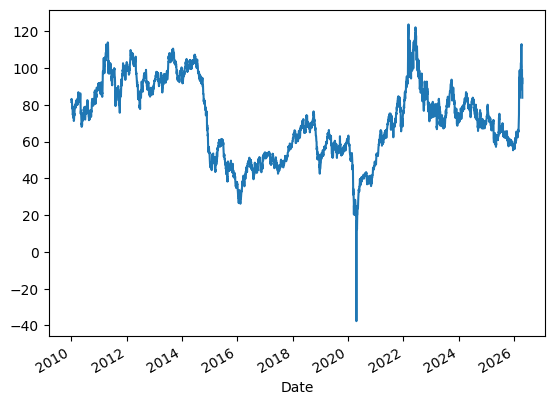

In [73]:
plt.figure()
df_raw.WTI_oil.plot()


In [18]:
# ── Запуск шага 2 ─────────────────────────────────────────────────────────────
# use_pcmci=False — быстрый режим (только LassoCV + Expert DAG)
# use_pcmci=True  — полный режим с PCMCI+ (требует tigramite)

var_selection = run_variable_selection(
    'WTI_oil',
    use_pcmci=True,   # ← поменяйте на True если установлен tigramite
    tau_max=4,
    pc_alpha=0.05,
)

print("\n" + "="*62)
print("  ИТОГ: контрольные наборы переменных")
print("="*62)
for target, info in var_selection.items():
    print(f"\n  {target}  [{info['freq']}]")
    print(f"    Heuristic  : {info['heuristic']}")
    print(f"    Expert DAG : {info['causal_expert']}")
    print(f"    PCMCI+     : {info['causal_pc']}")

14:35:10 │ INFO    │   [WTI_oil] Предфильтр: 6/13 кандидатов



  ИТОГ: контрольные наборы переменных

  WTI_oil  [D]
    Heuristic  : ['Brent', 'Copper', 'Yield10Y']
    Expert DAG : ['VIX', 'SP500', 'Yield10Y', 'InflationCPI', 'Copper', 'Silver']
    PCMCI+     : ['Cushing_stocks', 'SP500', 'Brent']


---
## 🎯 Шаг 3: Каузальные модели прогнозирования

Четыре метода × три набора контролей × несколько горизонтов:
1. **SCM (DoWhy)** — Structural Causal Model + Ridge/GBM
2. **DML** — Double Machine Learning (residual-on-residual)
3. **VAR+Granger** — Vector Autoregression с отбором по Granger
4. **IV-2SLS** — Instrumental Variables (2-Stage Least Squares)


In [76]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

TRAIN_RATIO = 0.80
HORIZONS = {
    "D":  [1, 5, 21], "B": [1, 5, 21], "ME": [1, 3, 6],
    "MS": [1, 3, 6],  "M": [1, 3, 6],  "W":  [1, 4, 13],
}

def get_horizons(freq): return HORIZONS.get(freq, [1, 5, 21])

def compute_metrics(y_true, y_pred, label=""):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_t, y_p = y_true[mask], y_pred[mask]
    if len(y_t) == 0:
        return {"RMSE": np.nan, "MAE": np.nan, "MAPE": np.nan, "R2": np.nan}
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    mae  = mean_absolute_error(y_t, y_p)
    mape = np.mean(np.abs((y_t - y_p) / (np.abs(y_t) + 1e-9))) * 100
    r2   = r2_score(y_t, y_p)
    metrics = {"RMSE": round(rmse,6), "MAE": round(mae,6), "MAPE": round(mape,4), "R2": round(r2,4)}
    if label:
        log.info(f"    {label}: RMSE={rmse:.4f}  MAE={mae:.4f}  MAPE={mape:.2f}%  R²={r2:.4f}")
    return metrics
# классическая разбивка
"""def train_test_split_ts(X, y, ratio=TRAIN_RATIO):
    n, cut = len(X), int(len(X) * ratio)
    return X.iloc[:cut], X.iloc[cut:], y.iloc[:cut], y.iloc[cut:]"""

# разбивка по геополитическому шоку
def train_test_split_ts(X, y, ratio=TRAIN_RATIO):
    date_index = X.index

    train_mask = date_index < '2026-02-28'
    test_mask = date_index >= '2026-02-28'

    return X[train_mask], X[test_mask], y[train_mask], y[test_mask]

In [20]:
def run_scm_dowhy(df, target, causes, controls, dag=None, horizon=1):
    log.info(f"  [SCM-DoWhy] {target}  h={horizon}")
    avail_causes   = [c for c in causes   if c in df.columns]
    avail_controls = [c for c in controls if c in df.columns]
    if not avail_causes:
        avail_causes = [c for c in df.columns if c != target and not c.startswith(f"{target}_")][:3]

    all_features = list(dict.fromkeys(avail_causes + avail_controls))
    if not all_features:
        return {"method": "SCM_SKIPPED", "metrics": {}, "predictions": {}}

    feat = pd.DataFrame(index=df.index)
    for lag in range(1, 4):
        feat[f"{target}_lag{lag}"] = df[target].shift(lag)
    for col in all_features:
        for lag in range(1, 3):
            feat[f"{col}_lag{lag}"] = df[col].shift(lag)
    feat["__y_h__"] = df[target].shift(-horizon)
    feat = feat.dropna()

    if len(feat) < 60:
        return {"method": "SCM_SKIPPED_insufficient_data", "metrics": {}}

    cut = int(len(feat) * TRAIN_RATIO)
    pred_cols = [c for c in feat.columns if c != "__y_h__"]
    X_all, y_all = feat[pred_cols].values, feat["__y_h__"].values
    X_tr, X_te, y_tr, y_te = X_all[:cut], X_all[cut:], y_all[:cut], y_all[cut:]

    # Попытка DoWhy
    try:
        import dowhy
        from dowhy import CausalModel
        from sklearn.linear_model import RidgeCV

        cause_feat_cols   = [c for c in pred_cols if any(c.startswith(f"{ca}_lag") for ca in avail_causes)]
        control_feat_cols = [c for c in pred_cols if any(c.startswith(f"{co}_lag") for co in avail_controls) and c not in cause_feat_cols]
        ar_cols           = [c for c in pred_cols if c.startswith(f"{target}_lag")]
        backdoor_cols     = list(dict.fromkeys(ar_cols + cause_feat_cols + control_feat_cols)) or pred_cols

        idx_bd = [pred_cols.index(c) for c in backdoor_cols if c in pred_cols]
        X_tr_bd, X_te_bd = X_tr[:, idx_bd], X_te[:, idx_bd]

        ridge = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0])
        ridge.fit(X_tr_bd, y_tr)
        pred_ridge = ridge.predict(X_te_bd)

        gbm = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
        gbm.fit(X_tr_bd, y_tr)
        pred_gbm = gbm.predict(X_te_bd)

        pred = 0.5 * pred_ridge + 0.5 * pred_gbm
        metrics = compute_metrics(y_te, pred, f"SCM_DoWhy(h={horizon})")
        return {
            "method": "SCM_DoWhy_ensemble",
            "metrics": metrics,
            "predictions": dict(zip(feat.index[cut:].strftime("%Y-%m-%d").tolist(), pred.tolist())),
        }

    except ImportError:
        pass
    except Exception as e:
        log.warning(f"    DoWhy ошибка: {e} — fallback Ridge")

    # Fallback: Ridge без DoWhy
    from sklearn.linear_model import RidgeCV
    ridge = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0])
    ridge.fit(X_tr, y_tr)
    pred = ridge.predict(X_te)
    metrics = compute_metrics(y_te, pred, f"SCM_Ridge(h={horizon})")
    return {
        "method": "SCM_Ridge_backdoor",
        "metrics": metrics,
        "predictions": dict(zip(feat.index[cut:].strftime("%Y-%m-%d").tolist(), pred.tolist())),
    }

In [21]:
def run_dml(df, target, causes, controls, horizon=1):
    log.info(f"  [DML] {target}  h={horizon}")
    avail_causes   = [c for c in causes   if c in df.columns]
    avail_controls = [c for c in controls if c in df.columns]

    feat = pd.DataFrame(index=df.index)
    for lag in range(1, 4):
        feat[f"{target}_lag{lag}"] = df[target].shift(lag)
    for col in list(dict.fromkeys(avail_causes + avail_controls)):
        for lag in range(1, 3):
            feat[f"{col}_lag{lag}"] = df[col].shift(lag)
    feat["__y_h__"] = df[target].shift(-horizon)
    feat = feat.dropna()

    if len(feat) < 60:
        return {"method": "DML_SKIPPED", "metrics": {}}

    cut = int(len(feat) * TRAIN_RATIO)
    pred_cols = [c for c in feat.columns if c != "__y_h__"]
    X_all, y_all = feat[pred_cols].values, feat["__y_h__"].values
    X_tr, X_te, y_tr, y_te = X_all[:cut], X_all[cut:], y_all[:cut], y_all[cut:]

    try:
        from econml.dml import LinearDML
        from sklearn.ensemble import RandomForestRegressor

        cause_idx  = [i for i, c in enumerate(pred_cols) if any(c.startswith(f"{ca}_lag") for ca in avail_causes)]
        ctrl_idx   = [i for i in range(len(pred_cols)) if i not in cause_idx]

        if not cause_idx:
            raise ValueError("Нет cause-колонок")

        T_tr, T_te = X_tr[:, cause_idx], X_te[:, cause_idx]
        W_tr, W_te = X_tr[:, ctrl_idx],  X_te[:, ctrl_idx]

        dml = LinearDML(
            model_y=RandomForestRegressor(n_estimators=100, random_state=42),
            model_t=RandomForestRegressor(n_estimators=100, random_state=42),
            cv=3, random_state=42,
        )
        dml.fit(y_tr, T_tr, X=None, W=W_tr)
        pred = dml.effect(T_te, X=None)
        if pred.ndim > 1: pred = pred.mean(axis=1)

        # Смещение: добавляем среднее тренировочного Y
        pred = pred + y_tr.mean()
        metrics = compute_metrics(y_te, pred, f"DML(h={horizon})")
        return {
            "method": "DML_LinearDML",
            "metrics": metrics,
            "predictions": dict(zip(feat.index[cut:].strftime("%Y-%m-%d").tolist(), pred.tolist())),
        }

    except ImportError:
        pass
    except Exception as e:
        log.warning(f"    DML ошибка: {e} — fallback Ridge")

    # Fallback: Ridge residual-on-residual
    from sklearn.linear_model import RidgeCV
    cause_idx = [i for i, c in enumerate(pred_cols) if any(c.startswith(f"{ca}_lag") for ca in avail_causes)] or list(range(min(3, len(pred_cols))))
    ctrl_idx  = [i for i in range(len(pred_cols)) if i not in cause_idx]

    W_tr = X_tr[:, ctrl_idx] if ctrl_idx else np.ones((len(X_tr), 1))
    W_te = X_te[:, ctrl_idx] if ctrl_idx else np.ones((len(X_te), 1))
    T_tr = X_tr[:, cause_idx]
    T_te = X_te[:, cause_idx]

    m_y = RidgeCV().fit(W_tr, y_tr)
    m_t = RidgeCV().fit(W_tr, T_tr)
    y_res = y_tr - m_y.predict(W_tr)
    T_res = T_tr - m_t.predict(W_tr)

    theta = RidgeCV().fit(T_res, y_res)
    pred  = theta.predict(T_te - m_t.predict(W_te)) + m_y.predict(W_te)
    metrics = compute_metrics(y_te, pred, f"DML_manual(h={horizon})")
    return {
        "method": "DML_manual",
        "metrics": metrics,
        "predictions": dict(zip(feat.index[cut:].strftime("%Y-%m-%d").tolist(), pred.tolist())),
    }

In [22]:
def run_var_granger(df, target, causes, controls, horizon=1):
    log.info(f"  [VAR+Granger] {target}  h={horizon}")
    avail = [c for c in (causes + controls) if c in df.columns]
    cols  = list(dict.fromkeys([target] + avail))[:8]
    sub   = df[cols].dropna()

    if len(sub) < 60:
        return {"method": "VAR_SKIPPED", "metrics": {}}

    cut = int(len(sub) * TRAIN_RATIO)
    train_df, test_df = sub.iloc[:cut], sub.iloc[cut:]

    # Granger-фильтр: оставляем переменные, Granger-причиняющие target
    try:
        from statsmodels.tsa.stattools import grangercausalitytests
        granger_cols = []
        for col in cols[1:]:
            try:
                gc = grangercausalitytests(train_df[[target, col]], maxlag=min(4, cut//10), verbose=False)
                min_p = min(res[0]["ssr_ftest"][1] for res in gc.values())
                if min_p < 0.10:
                    granger_cols.append(col)
            except Exception:
                pass
        if not granger_cols:
            granger_cols = cols[1:3]
    except Exception:
        granger_cols = cols[1:3]

    var_cols = list(dict.fromkeys([target] + granger_cols))

    try:
        from statsmodels.tsa.api import VAR
        max_lag = min(4, len(train_df) // (len(var_cols) * 4))
        if max_lag < 1: max_lag = 1

        model = VAR(train_df[var_cols])
        res   = model.fit(maxlags=max_lag, ic="aic")
        lag_order = res.k_ar

        # Rolling forecast
        preds = []
        history = train_df[var_cols].values.tolist()
        for i in range(len(test_df)):
            fc_input = np.array(history[-lag_order:])
            fc = res.forecast(fc_input, steps=horizon)
            preds.append(float(fc[-1, var_cols.index(target)]))
            history.append(test_df[var_cols].iloc[i].values.tolist())

        metrics = compute_metrics(test_df[target].values[:len(preds)], np.array(preds),
                                  f"VAR+Granger(h={horizon})")
        return {
            "method": f"VAR(lag={lag_order})+Granger",
            "metrics": metrics,
            "predictions": dict(zip(
                test_df.index.strftime("%Y-%m-%d").tolist()[:len(preds)], preds)),
            "granger_cols": granger_cols,
        }
    except Exception as e:
        log.warning(f"    VAR ошибка: {e} — fallback AR")

    # Fallback: простой AR
    from statsmodels.tsa.ar_model import AutoReg
    try:
        ar = AutoReg(train_df[target], lags=min(4, cut//10), old_names=False).fit()
        preds = []
        history = list(train_df[target])
        for i in range(len(test_df)):
            fc = ar.predict(start=len(history), end=len(history))
            preds.append(float(fc.iloc[0]))
            history.append(float(test_df[target].iloc[i]))
        metrics = compute_metrics(test_df[target].values[:len(preds)], np.array(preds), f"AR(h={horizon})")
        return {"method": "AR_fallback", "metrics": metrics,
                "predictions": dict(zip(test_df.index.strftime("%Y-%m-%d").tolist()[:len(preds)], preds))}
    except Exception as e2:
        log.error(f"    AR fallback ошибка: {e2}")
        return {"method": "VAR_FAILED", "metrics": {}}

In [23]:
def run_iv_2sls(df, target, causes, controls, instruments, horizon=1):
    log.info(f"  [IV-2SLS] {target}  h={horizon}")
    avail_causes   = [c for c in causes      if c in df.columns]
    avail_controls = [c for c in controls    if c in df.columns]
    avail_instrs   = [c for c in instruments if c in df.columns]

    feat = pd.DataFrame(index=df.index)
    for lag in range(1, 4):
        feat[f"{target}_lag{lag}"] = df[target].shift(lag)
    for col in list(dict.fromkeys(avail_causes + avail_controls + avail_instrs)):
        for lag in range(1, 3):
            feat[f"{col}_lag{lag}"] = df[col].shift(lag)
    feat["__y_h__"] = df[target].shift(-horizon)
    feat = feat.dropna()

    if len(feat) < 60:
        return {"method": "IV_SKIPPED", "metrics": {}}

    cut = int(len(feat) * TRAIN_RATIO)
    pred_cols = [c for c in feat.columns if c != "__y_h__"]
    feat_tr = feat.iloc[:cut][pred_cols]
    feat_te = feat.iloc[cut:][pred_cols]
    y_tr = feat.iloc[:cut]["__y_h__"]
    y_te = feat.iloc[cut:]["__y_h__"]

    endog_cols = [c for c in pred_cols if any(c.startswith(f"{ca}_lag") for ca in avail_causes)]
    exog_cols  = [c for c in pred_cols if any(c.startswith(f"{co}_lag") for co in avail_controls) or c.startswith(f"{target}_lag")]
    inst_cols  = [c for c in pred_cols if any(c.startswith(f"{iv}_lag") for iv in avail_instrs)]

    if not endog_cols:
        endog_cols = pred_cols[:min(2, len(pred_cols))]

    # Попытка linearmodels IV2SLS
    try:
        from linearmodels.iv import IV2SLS
        import statsmodels.api as sm

        y_sm     = y_tr
        endog_sm = feat_tr[endog_cols].iloc[:, 0] if endog_cols else feat_tr.iloc[:, 0]
        exog_sm  = sm.add_constant(feat_tr[exog_cols]) if exog_cols else sm.add_constant(feat_tr.iloc[:, :2])
        instr_sm = feat_tr[inst_cols] if inst_cols else None

        if instr_sm is not None and len(inst_cols) >= len(endog_cols):
            iv_model = IV2SLS(dependent=y_sm, exog=exog_sm, endog=endog_sm, instruments=instr_sm)
            res = iv_model.fit(cov_type="robust")
            exog_te = sm.add_constant(feat_te[exog_cols], has_constant="add") if exog_cols else sm.add_constant(feat_te.iloc[:, :2], has_constant="add")
            pred = res.predict(data=pd.concat([feat_te[[endog_cols[0]]], exog_te], axis=1))
            if hasattr(pred, "values"): pred = pred.values
            metrics = compute_metrics(y_te.values[:len(pred)], pred[:len(y_te)], f"IV_2SLS(h={horizon})")
            return {"method": "IV_2SLS", "metrics": metrics,
                    "predictions": dict(zip(feat_te.index.strftime("%Y-%m-%d").tolist(), pred.tolist()))}
    except Exception as e:
        log.warning(f"    linearmodels 2SLS ошибка: {e}")

    # Ручная 2SLS
    from sklearn.linear_model import LinearRegression
    W_tr = feat_tr[exog_cols].values if exog_cols else np.ones((len(feat_tr), 1))
    W_te = feat_te[exog_cols].values if exog_cols else np.ones((len(feat_te), 1))
    T_tr = feat_tr[endog_cols].values
    T_te = feat_te[endog_cols].values

    if inst_cols:
        Z_tr = feat_tr[inst_cols].values
        Z_te = feat_te[inst_cols].values
        s1 = LinearRegression().fit(np.hstack([Z_tr, W_tr]), T_tr)
        T_hat_tr = s1.predict(np.hstack([Z_tr, W_tr]))
        T_hat_te = s1.predict(np.hstack([Z_te, W_te]))
    else:
        T_hat_tr, T_hat_te = T_tr, T_te

    s2 = LinearRegression().fit(np.hstack([T_hat_tr, W_tr]), y_tr.values)
    pred = s2.predict(np.hstack([T_hat_te, W_te]))
    metrics = compute_metrics(y_te.values, pred, f"2SLS_manual(h={horizon})")
    return {"method": "2SLS_manual", "metrics": metrics,
            "predictions": dict(zip(feat_te.index.strftime("%Y-%m-%d").tolist(), pred.tolist()))}

In [37]:
def _run_one_control_set(df_stat, target, causes, controls, instruments, horizons, label):
    result_by_horizon = {}
    for h in horizons:
        log.info(f"    horizon={h} | controls={label}")
        h_res = {}
        h_res["causal_impact"] = run_scm_dowhy(df_stat, target, causes, controls, dag=ALL_DAGS.get(target), horizon=h)
        h_res["dml"]           = run_dml(df_stat, target, causes, controls, horizon=h)
        h_res["var_granger"]   = run_var_granger(df_stat, target, causes, controls, horizon=h)
        h_res["iv_2sls"]       = run_iv_2sls(df_stat, target, causes, controls, instruments, horizon=h)
        result_by_horizon[f"h{h}"] = h_res
    return result_by_horizon


def run_all_causal_models(target, var_selection):
    all_results = {}
    info = var_selection[target]
    
    dag = ALL_DAGS.get(target)

    log.info(f"\n{'═'*60}\n  КАУЗАЛЬНЫЕ МОДЕЛИ: {dag.name}  [freq={dag.freq}]\n{'═'*60}")
    df_raw  = load_dataset(dag)
    df_stat = prepare_stationary(df_raw, target)

    causes   = info.get("causes",      dag.causes)
    instrs   = info.get("instruments", dag.instruments)
    horizons = get_horizons(dag.freq)

    control_sets = {
            "controls_heuristic":     info.get("heuristic",     []),
            "controls_causal_expert": info.get("causal_expert", []),
            "controls_causal_pc":     info.get("causal_pc",     info.get("causal_expert", [])),
        }

    target_results = {"freq": dag.freq, "horizons": horizons, "asset": dag.name}
    for ctrl_label, ctrl_vars in control_sets.items():
        log.info(f"\n  ▸ {ctrl_label}: {ctrl_vars}")
        target_results[ctrl_label] = _run_one_control_set(df_stat, target, causes, ctrl_vars, instrs, horizons, label=ctrl_label)
        all_results[target] = target_results

    def _clean(obj):
        if isinstance(obj, dict): return {k: _clean(v) for k, v in obj.items()}
        if isinstance(obj, (list, tuple)): return [_clean(v) for v in obj]
        if isinstance(obj, (np.floating, np.integer)): return float(obj)
        if isinstance(obj, float) and (np.isnan(obj) or np.isinf(obj)): return None
        return obj

    out_path = RESULTS_DIR / "step3_causal_models.json"
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(_clean(all_results), f, ensure_ascii=False, indent=2)
    log.info(f"\n✓ Результаты step3 сохранены: {out_path}")
    return all_results

In [77]:
# ── Запуск шага 3 ─────────────────────────────────────────────────────────────
# Загружаем из файла если уже есть, иначе запускаем

sel_path = RESULTS_DIR / "step2_variable_selection.json"
if sel_path.exists():
    with open(sel_path) as f:
        var_sel_for_step3 = json.load(f)
else:
    var_sel_for_step3 = var_selection  # из текущей сессии

causal_results = run_all_causal_models(target, var_sel_for_step3)
print("\n✓ Шаг 3 завершён. Результаты:", RESULTS_DIR / "step3_causal_models.json")

15:58:56 │ INFO    │ 
════════════════════════════════════════════════════════════
  КАУЗАЛЬНЫЕ МОДЕЛИ: WTI Crude Oil  [freq=D]
════════════════════════════════════════════════════════════
15:58:57 │ INFO    │ 
  ▸ controls_heuristic: ['Brent', 'Copper', 'Yield10Y', 'DXY']
15:58:57 │ INFO    │     horizon=1 | controls=controls_heuristic
15:58:57 │ INFO    │   [SCM-DoWhy] WTI_oil  h=1
15:58:57 │ INFO    │     SCM_Ridge(h=1): RMSE=1.8919  MAE=1.2625  MAPE=72529982.73%  R²=-0.0075
15:58:57 │ INFO    │   [DML] WTI_oil  h=1
15:59:07 │ WARNING │     DML ошибка: TreatmentExpansionMixin.effect() got multiple values for argument 'X' — fallback Ridge
15:59:07 │ INFO    │     DML_manual(h=1): RMSE=1.8946  MAE=1.2648  MAPE=79255514.76%  R²=-0.0104
15:59:07 │ INFO    │   [VAR+Granger] WTI_oil  h=1
C:\Users\София Макашова\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A d


✓ Шаг 3 завершён. Результаты: results\step3_causal_models.json


---
## 📊 Шаг 4: Baseline модели

1. **ARIMA** — классический статистический baseline (direct-метод для h>1)
2. **Prophet** — Facebook Prophet (тренд + сезонность)
3. **Random Forest** — ML baseline с лаговыми фичами
4. **LSTM** — нейросетевой baseline (PyTorch или TF Keras)


In [39]:
from sklearn.preprocessing import MinMaxScaler

FREQ_PARAMS = {
    "D":  {"horizons": [1, 5, 21], "seq_len": 30, "lstm_epochs": 30},
    "B":  {"horizons": [1, 5, 21], "seq_len": 30, "lstm_epochs": 30},
    "W":  {"horizons": [1, 4, 13], "seq_len": 12, "lstm_epochs": 25},
    "ME": {"horizons": [1, 3, 6],  "seq_len": 12, "lstm_epochs": 50},
    "MS": {"horizons": [1, 3, 6],  "seq_len": 12, "lstm_epochs": 50},
    "M":  {"horizons": [1, 3, 6],  "seq_len": 12, "lstm_epochs": 50},
}
def get_freq_params(freq): return FREQ_PARAMS.get(freq, FREQ_PARAMS["D"])


def run_arima(df, target, horizon=1):
    log.info(f"  [ARIMA] {target}  h={horizon}")
    from statsmodels.tsa.stattools import adfuller

    series = df[target].dropna()
    n   = len(series)
    cut = int(n * TRAIN_RATIO)

    if horizon > 1:
        y_shifted = series.shift(-horizon).dropna()
        series_aligned = series.iloc[:len(y_shifted)]
        cut_d  = int(len(series_aligned) * TRAIN_RATIO)
        train_x = series_aligned.iloc[:cut_d]
        train_y = y_shifted.iloc[:cut_d]
        test_y  = y_shifted.iloc[cut_d:]
        test_x  = series_aligned.iloc[cut_d:]
    else:
        train_x = series.iloc[:cut]
        train_y = series.iloc[:cut]
        test_y  = series.iloc[cut:]
        test_x  = series.iloc[cut:]

    try:
        is_stationary = adfuller(train_y.dropna(), autolag="AIC")[1] < 0.05
    except Exception:
        is_stationary = False

    preds = []

    try:
        from pmdarima import auto_arima
        model = auto_arima(
            train_y, seasonal=False, stepwise=True, information_criterion="aic",
            max_p=4, max_q=4, d=0 if is_stationary else None, max_d=2,
            error_action="ignore", suppress_warnings=True, with_intercept=True,
        )
        for i in range(len(test_y)):
            fc = model.predict(n_periods=1)
            preds.append(float(fc[0]))
            model.update([test_y.iloc[i]])
        metrics = compute_metrics(test_y.values[:len(preds)], np.array(preds), f"ARIMA_direct(h={horizon})")
        return {"method": f"ARIMA{model.order}", "metrics": metrics,
                "predictions": dict(zip(test_x.index.strftime("%Y-%m-%d").tolist()[:len(preds)], preds)),
                "strategy": "direct" if horizon > 1 else "rolling_1step"}
    except ImportError:
        pass
    except Exception as e:
        log.warning(f"    auto_arima error: {e}")

    try:
        import statsmodels.tsa.arima.model as smarima
        d_order = 0 if is_stationary else 1
        arima_order = (2, d_order, 2)
        history = list(train_y)
        for i in range(len(test_y)):
            try:
                mod = smarima.ARIMA(history, order=arima_order)
                res = mod.fit(method_kwargs={"warn_convergence": False})
                preds.append(float(res.forecast(1).iloc[0]))
            except Exception:
                preds.append(float(np.mean(history[-20:])))
            history.append(float(test_y.iloc[i]))
        metrics = compute_metrics(test_y.values[:len(preds)], np.array(preds), f"ARIMA{arima_order}(h={horizon})")
        return {"method": f"ARIMA{arima_order}", "metrics": metrics,
                "predictions": dict(zip(test_x.index.strftime("%Y-%m-%d").tolist()[:len(preds)], preds)),
                "strategy": "direct" if horizon > 1 else "rolling_1step"}
    except Exception as e:
        log.error(f"    ARIMA fallback error: {e}")
        return {"method": "ARIMA_FAILED", "metrics": {}}

In [40]:
def run_prophet(df, target, extra_regressors=None, horizon=1):
    log.info(f"  [Prophet] {target}")
    try:
        from prophet import Prophet
    except ImportError:
        try:
            from fbprophet import Prophet
        except ImportError:
            log.warning("    prophet не установлен: pip install prophet")
            return {"method": "Prophet_SKIPPED", "metrics": {}}

    series = df[target].dropna()
    n, cut = len(series), int(len(series) * TRAIN_RATIO)
    freq_map = {"D": "D", "B": "B", "ME": "MS", "M": "MS"}
    freq = freq_map.get(pd.infer_freq(series.index) or "D", "D")

    prophet_df = pd.DataFrame({"ds": series.index, "y": series.values}).reset_index(drop=True)
    if extra_regressors:
        for reg in extra_regressors[:3]:
            if reg in df.columns:
                prophet_df[reg] = df[reg].reindex(series.index).ffill().values

    train_df = prophet_df.iloc[:cut]
    test_df  = prophet_df.iloc[cut:]

    try:
        m = Prophet(daily_seasonality=False, yearly_seasonality=(freq in ["D","B"]), weekly_seasonality=(freq in ["D","B"]))
        if extra_regressors:
            for reg in extra_regressors[:3]:
                if reg in train_df.columns:
                    m.add_regressor(reg)
        m.fit(train_df)

        future = test_df[["ds"] + ([r for r in (extra_regressors or []) if r in test_df.columns])]
        forecast = m.predict(future)
        pred = forecast["yhat"].values

        metrics = compute_metrics(test_df["y"].values[:len(pred)], pred[:len(test_df)], "Prophet")
        return {"method": "Prophet", "metrics": metrics,
                "predictions": dict(zip(test_df["ds"].dt.strftime("%Y-%m-%d").tolist(), pred.tolist()))}
    except Exception as e:
        log.warning(f"    Prophet ошибка: {e}")
        return {"method": "Prophet_FAILED", "metrics": {}}


def run_random_forest(df, target, feature_cols, horizon=1):
    log.info(f"  [RF] {target}  h={horizon}")
    avail = [c for c in feature_cols if c in df.columns and c != target]

    feat = pd.DataFrame(index=df.index)
    for lag in range(1, 6):
        feat[f"{target}_lag{lag}"] = df[target].shift(lag)
    for col in avail[:20]:
        for lag in range(0, 3):
            key = col if lag == 0 else f"{col}_lag{lag}"
            feat[key] = df[col].shift(lag)
    feat["__y__"] = df[target].shift(-horizon)
    feat = feat.dropna()

    if len(feat) < 50:
        return {"method": "RF_SKIPPED", "metrics": {}}

    cut = int(len(feat) * TRAIN_RATIO)
    xcols = [c for c in feat.columns if c != "__y__"]
    X_tr, X_te = feat[xcols].iloc[:cut].values, feat[xcols].iloc[cut:].values
    y_tr, y_te = feat["__y__"].iloc[:cut].values, feat["__y__"].iloc[cut:].values

    rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    pred = rf.predict(X_te)
    metrics = compute_metrics(y_te, pred, f"RF(h={horizon})")
    return {"method": "RandomForest", "metrics": metrics,
            "predictions": dict(zip(feat.index[cut:].strftime("%Y-%m-%d").tolist(), pred.tolist()))}

In [41]:
def run_lstm(df, target, feature_cols, seq_len=30, horizon=1, epochs=30):
    log.info(f"  [LSTM] {target}  h={horizon}")

    # PyTorch
    try:
        import torch
        import torch.nn as nn
        from torch.utils.data import TensorDataset, DataLoader

        avail = [c for c in feature_cols if c in df.columns]
        cols  = [target] + avail[:9]
        sub   = df[cols].dropna()
        n, cut = len(sub), int(len(sub) * TRAIN_RATIO)

        scaler = MinMaxScaler()
        data_scaled = scaler.fit_transform(sub.values)

        def make_seqs(arr, seq, h):
            Xs, ys = [], []
            for i in range(len(arr) - seq - h + 1):
                Xs.append(arr[i:i+seq])
                ys.append(arr[i+seq+h-1, 0])
            return np.array(Xs), np.array(ys)

        X_tr, y_tr = make_seqs(data_scaled[:cut], seq_len, horizon)
        X_te, y_te = make_seqs(data_scaled[cut - seq_len:], seq_len, horizon)

        if len(X_tr) < 20:
            return {"method": "LSTM_SKIPPED", "metrics": {}}

        class LSTMModel(nn.Module):
            def __init__(self, n_feat, hidden=64):
                super().__init__()
                self.lstm = nn.LSTM(n_feat, hidden, batch_first=True, num_layers=2, dropout=0.2)
                self.fc   = nn.Linear(hidden, 1)
            def forward(self, x):
                out, _ = self.lstm(x)
                return self.fc(out[:, -1, :]).squeeze(-1)

        device = "cuda" if torch.cuda.is_available() else "cpu"
        model  = LSTMModel(n_feat=len(cols)).to(device)
        optim  = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
        crit   = nn.MSELoss()
        sched  = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, patience=5, factor=0.5)

        X_t = torch.FloatTensor(X_tr).to(device)
        y_t = torch.FloatTensor(y_tr).to(device)
        dl  = DataLoader(TensorDataset(X_t, y_t), batch_size=32, shuffle=False)

        model.train()
        for epoch in range(epochs):
            epoch_loss = 0.0
            for xb, yb in dl:
                optim.zero_grad()
                loss = crit(model(xb), yb)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optim.step()
                epoch_loss += loss.item()
            sched.step(epoch_loss)

        model.eval()
        with torch.no_grad():
            preds_scaled = model(torch.FloatTensor(X_te).to(device)).cpu().numpy()

        pad = np.zeros((len(preds_scaled), len(cols)))
        pad[:, 0] = preds_scaled
        preds_inv = scaler.inverse_transform(pad)[:, 0]

        pad2 = np.zeros((len(y_te), len(cols)))
        pad2[:, 0] = y_te
        true_inv = scaler.inverse_transform(pad2)[:, 0]

        metrics = compute_metrics(true_inv, preds_inv, "LSTM_PyTorch")
        return {"method": "LSTM_PyTorch", "metrics": metrics, "predictions": {}}

    except ImportError:
        pass
    except Exception as e:
        log.warning(f"    LSTM PyTorch ошибка: {e}")

    # TF Keras fallback
    try:
        import tensorflow as tf
        avail = [c for c in feature_cols if c in df.columns]
        cols  = [target] + avail[:9]
        sub   = df[cols].dropna()
        n, cut = len(sub), int(len(sub) * TRAIN_RATIO)

        scaler = MinMaxScaler()
        data_scaled = scaler.fit_transform(sub.values)

        def make_seqs(arr, seq, h):
            Xs, ys = [], []
            for i in range(len(arr) - seq - h + 1):
                Xs.append(arr[i:i+seq])
                ys.append(arr[i+seq+h-1, 0])
            return np.array(Xs), np.array(ys)

        X_tr, y_tr = make_seqs(data_scaled[:cut], seq_len, horizon)
        X_te, y_te = make_seqs(data_scaled[cut-seq_len:], seq_len, horizon)

        if len(X_tr) < 20:
            return {"method": "LSTM_SKIPPED", "metrics": {}}

        model = tf.keras.Sequential([
            tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(seq_len, len(cols))),
            tf.keras.layers.Dropout(0.2),
            tf.keras.layers.LSTM(32),
            tf.keras.layers.Dense(1),
        ])
        model.compile(optimizer="adam", loss="mse")
        model.fit(X_tr, y_tr, epochs=epochs, batch_size=32, verbose=0, validation_split=0.1)
        preds_scaled = model.predict(X_te, verbose=0).flatten()
        pad = np.zeros((len(preds_scaled), len(cols)))
        pad[:, 0] = preds_scaled
        preds_inv = scaler.inverse_transform(pad)[:, 0]
        pad2 = np.zeros((len(y_te), len(cols)))
        pad2[:, 0] = y_te
        true_inv = scaler.inverse_transform(pad2)[:, 0]
        metrics = compute_metrics(true_inv, preds_inv, "LSTM_Keras")
        return {"method": "LSTM_Keras", "metrics": metrics, "predictions": {}}

    except ImportError:
        log.warning("    LSTM: ни PyTorch, ни TF не найдены — пропуск")
        return {"method": "LSTM_SKIPPED", "metrics": {}}
    except Exception as e:
        log.warning(f"    LSTM Keras ошибка: {e}")
        return {"method": "LSTM_FAILED", "metrics": {}}

In [43]:
def run_all_baselines(target, var_selection):
    all_results = {}
    info = var_selection[target]
    dag = ALL_DAGS.get(target)

    log.info(f"\n{'═'*60}\n  BASELINE: {dag.name}  [freq={dag.freq}]\n{'═'*60}")
    df_raw  = load_dataset(dag)
    df_stat = prepare_stationary(df_raw, target)

    all_features = [c for c in df_stat.columns if c != target]
    controls     = info.get("heuristic", [])
    fparams      = get_freq_params(dag.freq)
    horizons, seq_len, epochs = fparams["horizons"], fparams["seq_len"], fparams["lstm_epochs"]

    target_results = {"freq": dag.freq, "horizons": horizons}
    for h in horizons:
        log.info(f"\n  ▸ horizon = {h}")
        h_res = {}
        h_res["arima"]         = run_arima(df_stat, target, horizon=h)
        h_res["prophet"]       = run_prophet(df_raw, target, extra_regressors=controls[:3], horizon=h)
        h_res["random_forest"] = run_random_forest(df_stat, target, all_features[:30], horizon=h)
        h_res["lstm"]          = run_lstm(df_raw, target, controls[:8], seq_len=seq_len, horizon=h, epochs=epochs)
        target_results[f"h{h}"] = h_res

    all_results[target] = target_results

    def _clean(obj):
        if isinstance(obj, dict): return {k: _clean(v) for k, v in obj.items()}
        if isinstance(obj, (list, tuple)): return [_clean(v) for v in obj]
        if isinstance(obj, (np.floating, np.integer)): return float(obj)
        if isinstance(obj, float) and (np.isnan(obj) or np.isinf(obj)): return None
        return obj

    out_path = RESULTS_DIR / "step4_baselines.json"
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(_clean(all_results), f, ensure_ascii=False, indent=2)
    log.info(f"\n✓ Результаты step4 сохранены: {out_path}")
    return all_results

In [78]:
# ── Запуск шага 4 ─────────────────────────────────────────────────────────────
sel_path = RESULTS_DIR / "step2_variable_selection.json"
if sel_path.exists():
    with open(sel_path) as f:
        var_sel_for_step4 = json.load(f)
else:
    var_sel_for_step4 = var_selection

baseline_results = run_all_baselines(target, var_sel_for_step4)
print("\n✓ Шаг 4 завершён. Результаты:", RESULTS_DIR / "step4_baselines.json")

16:00:32 │ INFO    │ 
════════════════════════════════════════════════════════════
  BASELINE: WTI Crude Oil  [freq=D]
════════════════════════════════════════════════════════════
16:00:33 │ INFO    │ 
  ▸ horizon = 1
16:00:33 │ INFO    │   [ARIMA] WTI_oil  h=1
C:\Users\София Макашова\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
16:00:36 │ WARNING │     auto_arima error: 0
16:08:30 │ INFO    │     ARIMA(2, 0, 2)(h=1): RMSE=1.9171  MAE=1.2807  MAPE=156455688.61%  R²=-0.0350
16:08:30 │ INFO    │   [Prophet] WTI_oil
16:08:30 │ INFO    │ Chain [1] start processing
16:08:31 │ INFO    │ Chain [1] done processing
16:08:31 │ INFO    │     Prophet: RMSE=1.8053  MAE=1.2153  MAPE=1.65%  R²=0.9617
16:08:31 │ INFO    │   [RF] WTI_


✓ Шаг 4 завершён. Результаты: results\step4_baselines.json


---
## 📈 Шаг 5: Сравнение и отчёт

Выходы:
- `results/full_comparison.csv` — все метрики
- `results/summary_h1_RMSE.csv` — сводная таблица h=1
- `results/dag_comparison.csv` — Expert vs PC DAG
- `figures/` — графики (heatmap, bar charts, horizon progression)


In [46]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

CAUSAL_METHODS   = ["causal_impact", "dml", "var_granger", "iv_2sls"]
BASELINE_METHODS = ["arima", "prophet", "random_forest", "lstm"]
CONTROL_SETS     = ["controls_heuristic", "controls_causal_expert", "controls_causal_pc"]

METHOD_LABELS = {
    "causal_impact": "CausalImpact", "dml": "DML",
    "var_granger": "VAR+Granger",    "iv_2sls": "IV-2SLS",
    "arima": "ARIMA",                "prophet": "Prophet",
    "random_forest": "RandomForest", "lstm": "LSTM",
}
CTRL_LABELS = {
    "controls_heuristic":     "Heuristic-Z",
    "controls_causal_expert": "Expert-DAG",
    "controls_causal_pc":     "PC-DAG",
}
ASSET_LABELS = {
    "WTI_oil": "WTI Oil",  "NatGas":  "Nat.Gas",  "Gold":    "Gold",
    "EURUSD":  "EUR/USD",  "GBPUSD":  "GBP/USD",  "USDJPY":  "USD/JPY",
    "CPI":     "CPI",      "IndProd": "IndProd",   "UMCSENT": "UMCSENT",
    "BTC":     "Bitcoin",  "ETH":     "Ethereum",
}
ASSET_GROUP = {
    "WTI_oil": "A", "NatGas": "A", "Gold": "A",
    "EURUSD":  "B", "GBPUSD": "B", "USDJPY": "B",
    "CPI":     "C", "IndProd": "C", "UMCSENT": "C",
    "BTC":     "D", "ETH": "D",
}
GROUP_COLORS = {"A": "#FF6B6B", "B": "#4ECDC4", "C": "#45B7D1", "D": "#FFA07A"}
COLORS_CAUSAL   = ["#2196F3", "#00BCD4", "#4CAF50", "#8BC34A"]
COLORS_BASELINE = ["#FF9800", "#F44336", "#9C27B0", "#795548"]

_DARK_BG  = "#FFFFFF"
_CARD_BG  = "#F5F5F5"
_GRID_CLR = "#E0E0E0"

In [47]:
def load_results():
    c_path = RESULTS_DIR / "step3_causal_models.json"
    b_path = RESULTS_DIR / "step4_baselines.json"
    causal   = json.loads(c_path.read_text()) if c_path.exists() else {}
    baseline = json.loads(b_path.read_text()) if b_path.exists() else {}
    return causal, baseline


def build_full_df(causal, baseline):
    rows = []
    for target, tdata in causal.items():
        if not isinstance(tdata, dict): continue
        freq     = tdata.get("freq", "D")
        horizons = tdata.get("horizons", [1])
        for ctrl_key in CONTROL_SETS:
            ctrl_data = tdata.get(ctrl_key, {})
            if not isinstance(ctrl_data, dict): continue
            for h in horizons:
                hkey = f"h{h}"
                h_data = ctrl_data.get(hkey, {})
                if not isinstance(h_data, dict): continue
                for method in CAUSAL_METHODS:
                    m_data  = h_data.get(method, {})
                    metrics = m_data.get("metrics", {}) if isinstance(m_data, dict) else {}
                    rows.append({
                        "Asset": ASSET_LABELS.get(target, target), "Target": target,
                        "Group": ASSET_GROUP.get(target, "?"), "Freq": freq,
                        "Horizon": h, "ControlSet": CTRL_LABELS.get(ctrl_key, ctrl_key),
                        "Method": METHOD_LABELS.get(method, method), "Type": "Causal",
                        "RMSE": metrics.get("RMSE"), "MAE": metrics.get("MAE"),
                        "MAPE": metrics.get("MAPE"), "R2": metrics.get("R2"),
                    })

    for target, tdata in baseline.items():
        if not isinstance(tdata, dict): continue
        freq     = tdata.get("freq", "D")
        horizons = tdata.get("horizons", [1])
        for h in horizons:
            hkey   = f"h{h}"
            h_data = tdata.get(hkey, {})
            if not isinstance(h_data, dict): continue
            for method in BASELINE_METHODS:
                m_data  = h_data.get(method, {})
                metrics = m_data.get("metrics", {}) if isinstance(m_data, dict) else {}
                rows.append({
                    "Asset": ASSET_LABELS.get(target, target), "Target": target,
                    "Group": ASSET_GROUP.get(target, "?"), "Freq": freq,
                    "Horizon": h, "ControlSet": "Baseline (no Z)",
                    "Method": METHOD_LABELS.get(method, method), "Type": "Baseline",
                    "RMSE": metrics.get("RMSE"), "MAE": metrics.get("MAE"),
                    "MAPE": metrics.get("MAPE"), "R2": metrics.get("R2"),
                })

    df = pd.DataFrame(rows)
    if df.empty: return df
    for col in ["RMSE", "MAE", "MAPE", "R2"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def build_summary_h1(full_df, metric="RMSE"):
    h1 = full_df[full_df["Horizon"] == 1].copy()
    pivot_c = h1[h1["Type"]=="Causal"].pivot_table(
        index="Asset", columns=["ControlSet","Method"], values=metric, aggfunc="mean")
    pivot_b = h1[h1["Type"]=="Baseline"].pivot_table(
        index="Asset", columns="Method", values=metric, aggfunc="mean")
    if not pivot_c.empty:
        pivot_c.columns = [f"{c} | {m}" for c, m in pivot_c.columns]
    return pivot_c.join(pivot_b, how="outer") if not pivot_c.empty else pivot_b


def build_dag_comparison(full_df, metric="RMSE"):
    expert = full_df[full_df["ControlSet"]=="Expert-DAG"].copy()
    pc     = full_df[full_df["ControlSet"]=="PC-DAG"].copy()
    if expert.empty or pc.empty:
        return pd.DataFrame()
    merged = expert.merge(pc, on=["Target","Horizon","Method"], suffixes=("_expert","_pc"))
    merged["diff_pc_minus_expert"] = merged[f"{metric}_pc"] - merged[f"{metric}_expert"]
    return merged

In [49]:
def _dark_fig(w, h):
    fig = plt.figure(figsize=(w, h), facecolor=_DARK_BG)
    return fig

def _style_ax(ax, title="", xlabel="", ylabel="", xticks=None):
    ax.set_facecolor(_CARD_BG)
    ax.grid(True, color=_GRID_CLR, linewidth=0.5, alpha=0.7)
    ax.spines[["top","right"]].set_visible(False)
    ax.spines[["left","bottom"]].set_color(_GRID_CLR)
    if title:  ax.set_title(title, fontsize=11, color="black", pad=8, fontweight="bold")
    if xlabel: ax.set_xlabel(xlabel, color="black", fontsize=9)
    if ylabel: ax.set_ylabel(ylabel, color="black", fontsize=9)
    ax.tick_params(colors="black")


def plot_heatmap_by_horizon(full_df, metric="RMSE", horizon=1):
    sub = full_df[full_df["Horizon"] == horizon].copy()
    if sub.empty: return

    pivot = sub.pivot_table(
        index="Asset", columns=["Type","ControlSet","Method"],
        values=metric, aggfunc="mean"
    )
    if pivot.empty: return

    pivot.columns = [f"{t}|{m}" if cs=="Baseline (no Z)" else f"{cs[:3]}|{m}" for t,cs,m in pivot.columns]
    pivot = pivot.dropna(how="all").dropna(axis=1, how="all")

    fig = _dark_fig(max(14, len(pivot.columns)*1.2), max(6, len(pivot)*0.7))
    ax  = fig.add_subplot(111)

    cmap = LinearSegmentedColormap.from_list("rg", ["#27AE60","#F5CBA7","#E74C3C"])
    im = ax.imshow(pivot.values.astype(float), aspect="auto", cmap=cmap)

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right", fontsize=7, color="black")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9, color="black")
    ax.set_title(f"Heatmap {metric} — Horizon h={horizon}", fontsize=12, color="black", pad=10)

    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
    plt.tight_layout()
    path = FIGURES_DIR / f"heatmap_{metric}_h{horizon}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight", facecolor=_DARK_BG)
    log.info(f"  ✓ {path.name}")
    plt.close()


def plot_horizon_progression(full_df, metric="RMSE"):
    horiz = full_df.groupby(["Horizon","Type"])[metric].mean().reset_index()
    if horiz.empty: return

    fig = _dark_fig(9, 5)
    ax  = fig.add_subplot(111)
    _style_ax(ax, title=f"Деградация {metric} по горизонтам прогноза",
              xlabel="Горизонт (шагов)", ylabel=f"Среднее {metric}")

    for i, (tp, grp) in enumerate(horiz.groupby("Type")):
        color = COLORS_CAUSAL[0] if tp == "Causal" else COLORS_BASELINE[0]
        ax.plot(grp["Horizon"], grp[metric], marker="o", label=tp, color=color, linewidth=2)
        ax.fill_between(grp["Horizon"], grp[metric], alpha=0.12, color=color)

    ax.legend(facecolor=_CARD_BG, edgecolor=_GRID_CLR, fontsize=9)
    plt.tight_layout()
    path = FIGURES_DIR / f"horizon_progression_{metric}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight", facecolor=_DARK_BG)
    log.info(f"  ✓ {path.name}")
    plt.close()


def plot_dag_divergence(dag_df, metric="RMSE"):
    if dag_df.empty: return
    agg = dag_df.groupby("Target")["diff_pc_minus_expert"].mean().sort_values()

    fig = _dark_fig(10, max(5, len(agg) * 0.6))
    ax  = fig.add_subplot(111)
    _style_ax(ax, title=f"Expert-DAG vs PC-DAG: Δ{metric} (PC − Expert) зелёный = PC лучше",
              xlabel=f"Δ{metric}")

    colors  = ["#27AE60" if v < 0 else "#E74C3C" for v in agg.values]
    ylabels = [ASSET_LABELS.get(t, t) for t in agg.index]
    bars = ax.barh(ylabels, agg.values, color=colors, edgecolor="black", linewidth=0.4, alpha=0.85)
    ax.axvline(0, color="black", linewidth=0.8)

    max_abs = abs(agg.values).max() if len(agg) > 0 else 1
    for bar, val in zip(bars, agg.values):
        ax.text(val + np.sign(val)*max_abs*0.02, bar.get_y()+bar.get_height()/2,
                f"{val:+.4f}", va="center", ha="left" if val >= 0 else "right",
                color="black", fontsize=8)

    pc_wins  = (agg < 0).sum()
    exp_wins = (agg >= 0).sum()
    fig.text(0.98, 0.02, f"PC-DAG лучше: {pc_wins}/{len(agg)}\nExpert-DAG лучше: {exp_wins}/{len(agg)}",
             ha="right", va="bottom", color="#888888", fontsize=9, transform=fig.transFigure)

    plt.tight_layout()
    path = FIGURES_DIR / f"dag_divergence_{metric}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight", facecolor=_DARK_BG)
    log.info(f"  ✓ {path.name}")
    plt.close()


def plot_causal_vs_baseline(full_df, metric="RMSE", horizon=1):
    sub = full_df[full_df["Horizon"] == horizon].copy()
    if sub.empty: return

    rows = []
    for tgt in sub["Target"].unique():
        tsub  = sub[sub["Target"] == tgt]
        c_val = tsub[tsub["Type"]=="Causal"][metric].dropna()
        b_val = tsub[tsub["Type"]=="Baseline"][metric].dropna()
        if c_val.empty or b_val.empty: continue
        rows.append({"label": ASSET_LABELS.get(tgt, tgt), "causal": c_val.min(),
                     "baseline": b_val.min(), "group": ASSET_GROUP.get(tgt, "A")})
    if not rows: return

    df_plot = pd.DataFrame(rows)
    x, w    = np.arange(len(df_plot)), 0.38

    fig = _dark_fig(max(12, len(df_plot)*1.3), 5.5)
    ax  = fig.add_subplot(111)
    _style_ax(ax, title=f"Лучший каузальный vs Лучший baseline — {metric}, h={horizon}", ylabel=metric)

    ax.bar(x-w/2, df_plot["causal"],   w, label="Best Causal",   color="#2196F3", edgecolor="black", linewidth=0.4, alpha=0.85)
    ax.bar(x+w/2, df_plot["baseline"], w, label="Best Baseline", color="#FF9800", edgecolor="black", linewidth=0.4, alpha=0.85)

    for i, row in df_plot.iterrows():
        pct   = (row["baseline"] - row["causal"]) / (row["baseline"] + 1e-9) * 100
        color = "#27AE60" if pct > 0 else "#E74C3C"
        ypos  = max(row["causal"], row["baseline"]) * 1.03
        ax.text(x[i], ypos, f"{pct:+.1f}%", ha="center", fontsize=8, color=color, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(df_plot["label"], rotation=30, ha="right", fontsize=9, color="black")
    ax.legend(facecolor=_CARD_BG, edgecolor=_GRID_CLR, fontsize=9)
    plt.tight_layout()

    path = FIGURES_DIR / f"causal_vs_baseline_{metric}_h{horizon}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight", facecolor=_DARK_BG)
    log.info(f"  ✓ {path.name}")
    plt.close()

In [50]:
def print_report(full_df, dag_df):
    SEP = "═" * 72
    print(f"\n{SEP}\n  ИТОГОВЫЙ ОТЧЁТ: Каузальный пайплайн прогнозирования\n{SEP}")

    print("\n▸ Лучший метод по каждому активу (RMSE, h=1):")
    h1 = full_df[full_df["Horizon"] == 1]
    for tgt, grp in h1.groupby("Target"):
        valid = grp.dropna(subset=["RMSE"])
        if valid.empty: continue
        best = valid.loc[valid["RMSE"].idxmin()]
        ctrl = (f" [{best.get('ControlSet', '')}]" if best["Type"] == "Causal" else "")
        print(f"  {ASSET_LABELS.get(tgt, tgt):<12}  {best['Method']:<18}{ctrl:<24}  RMSE={best['RMSE']:.4f}")

    if not dag_df.empty:
        by_asset = dag_df.groupby("Target")["diff_pc_minus_expert"].mean()
        pc_wins  = (by_asset < 0).sum()
        exp_wins = (by_asset >= 0).sum()
        print(f"\n▸ Expert-DAG vs PC-DAG (RMSE):")
        print(f"   PC-DAG лучше     : {pc_wins}/{len(by_asset)} активов")
        print(f"   Expert-DAG лучше : {exp_wins}/{len(by_asset)} активов")
        for tgt, diff in by_asset.sort_values().items():
            winner = "← PC" if diff < 0 else "← Expert"
            print(f"   {ASSET_LABELS.get(tgt, tgt):<12}  Δ={diff:+.5f}  {winner}")

    print(f"\n▸ Средний RMSE по горизонтам прогноза:")
    horiz = full_df.groupby(["Horizon","Type"])["RMSE"].mean().unstack("Type").round(4)
    print(horiz.to_string())

    print(f"\n▸ Среднее RMSE по группам активов (h=1, лучший метод):")
    h1_best = h1.groupby("Target")["RMSE"].min().reset_index()
    h1_best["Group"] = h1_best["Target"].map(ASSET_GROUP)
    grp_avg = h1_best.groupby("Group")["RMSE"].mean().round(4)
    group_names = {"A": "Энергетика/Металлы", "B": "Форекс", "C": "Макро США", "D": "Крипто"}
    for g, v in grp_avg.items():
        print(f"   Группа {g} ({group_names.get(g, g)}): {v:.4f}")

    print(f"\n{SEP}")

In [82]:
def run_comparison():
    log.info("Загружаем результаты step3 и step4...")
    causal, baseline = load_results()

    if not causal and not baseline:
        log.error("Результаты не найдены. Запустите шаги 3 и 4 сначала.")
        return None, None

    full_df  = build_full_df(causal, baseline)
    summary  = build_summary_h1(full_df, metric="RMSE")
    dag_comp = build_dag_comparison(full_df, metric="RMSE")

    full_df.to_csv(RESULTS_DIR  / "full_comparison.csv",  index=False)
    summary.to_csv(RESULTS_DIR  / "summary_h1_RMSE.csv")
    dag_comp.to_csv(RESULTS_DIR / "dag_comparison.csv",   index=False)
    log.info("  ✓ CSV-таблицы сохранены")

    horizons = sorted(full_df["Horizon"].dropna().unique().astype(int).tolist())
    for h in horizons:
        plot_heatmap_by_horizon(full_df, metric="RMSE", horizon=h)
        plot_causal_vs_baseline(full_df, metric="RMSE", horizon=h)
    plot_horizon_progression(full_df, metric="RMSE")
    plot_dag_divergence(dag_comp, metric="RMSE")

    print_report(full_df, dag_comp)
    return full_df, dag_comp


# ── Запуск шага 5 ─────────────────────────────────────────────────────────────
full_df, dag_comp = run_comparison()

16:40:40 │ INFO    │ Загружаем результаты step3 и step4...
16:40:40 │ INFO    │   ✓ CSV-таблицы сохранены
16:40:40 │ INFO    │   ✓ heatmap_RMSE_h1.png
16:40:41 │ INFO    │   ✓ causal_vs_baseline_RMSE_h1.png
16:40:41 │ INFO    │   ✓ heatmap_RMSE_h5.png
16:40:41 │ INFO    │   ✓ causal_vs_baseline_RMSE_h5.png
16:40:41 │ INFO    │   ✓ heatmap_RMSE_h21.png
16:40:42 │ INFO    │   ✓ causal_vs_baseline_RMSE_h21.png
16:40:42 │ INFO    │   ✓ horizon_progression_RMSE.png
16:40:42 │ INFO    │   ✓ dag_divergence_RMSE.png



════════════════════════════════════════════════════════════════════════
  ИТОГОВЫЙ ОТЧЁТ: Каузальный пайплайн прогнозирования
════════════════════════════════════════════════════════════════════════

▸ Лучший метод по каждому активу (RMSE, h=1):
  WTI Oil       Prophet                                     RMSE=1.8053

▸ Expert-DAG vs PC-DAG (RMSE):
   PC-DAG лучше     : 1/1 активов
   Expert-DAG лучше : 0/1 активов
   WTI Oil       Δ=-0.00197  ← PC

▸ Средний RMSE по горизонтам прогноза:
Type     Baseline  Causal
Horizon                  
1          2.8070  1.9006
5          3.3939  1.8878
21         5.7703  1.9010

▸ Среднее RMSE по группам активов (h=1, лучший метод):
   Группа A (Энергетика/Металлы): 1.8053

════════════════════════════════════════════════════════════════════════


---
## 📁 Просмотр результатов

Отображаем сводные таблицы и графики прямо в ноутбуке.


In [83]:
# Сводная таблица h=1
if full_df is not None and not full_df.empty:
    summary_view = build_summary_h1(full_df, metric="RMSE")
    print("\nСводная таблица RMSE на горизонте h=1:")
    display(summary_view.round(4).T.sort_values('WTI Oil'))


Сводная таблица RMSE на горизонте h=1:


Asset,WTI Oil
Prophet,1.8053
Expert-DAG | DML,1.8909
Expert-DAG | IV-2SLS,1.8911
Expert-DAG | CausalImpact,1.8911
Heuristic-Z | CausalImpact,1.8919
PC-DAG | CausalImpact,1.8944
Heuristic-Z | DML,1.8946
PC-DAG | IV-2SLS,1.8946
PC-DAG | DML,1.8946
Expert-DAG | VAR+Granger,1.9105



causal_vs_baseline_RMSE_h1.png


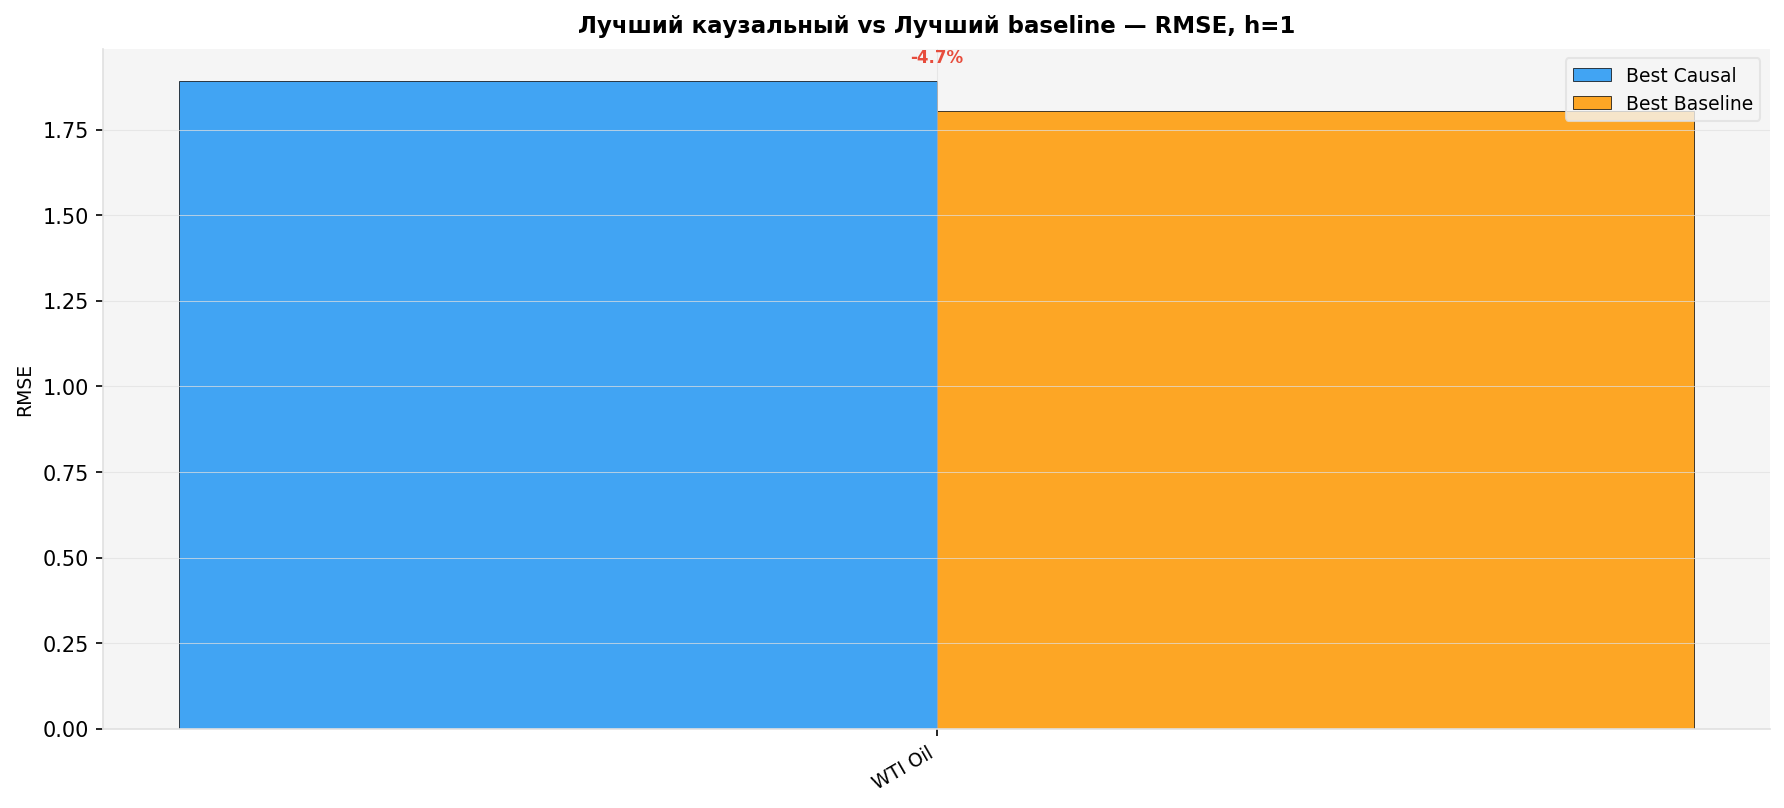


causal_vs_baseline_RMSE_h21.png


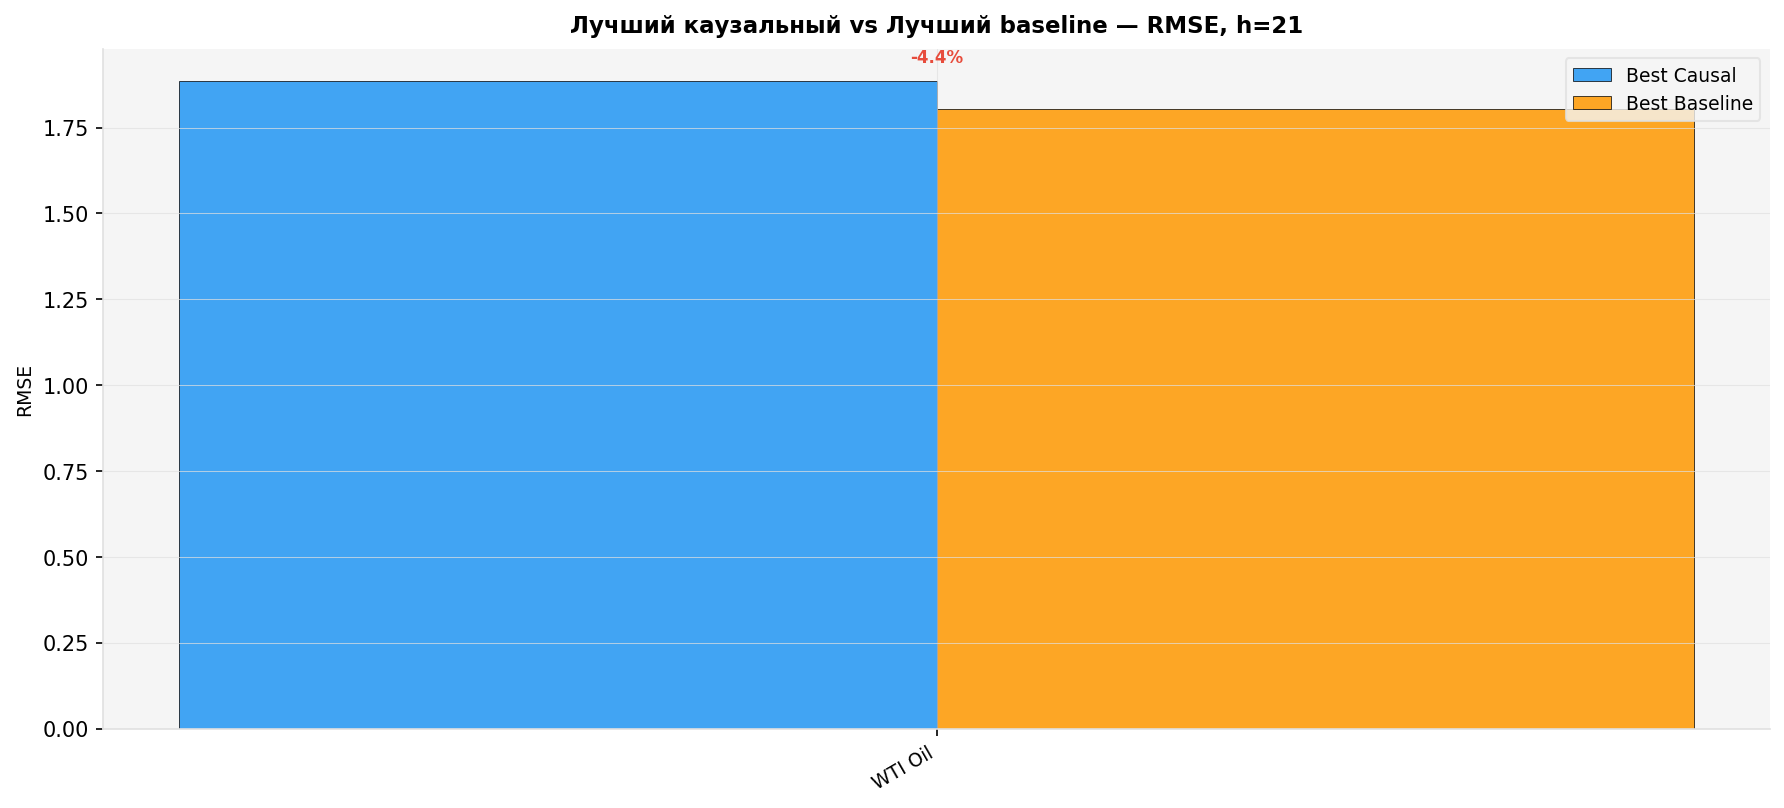


causal_vs_baseline_RMSE_h3.png


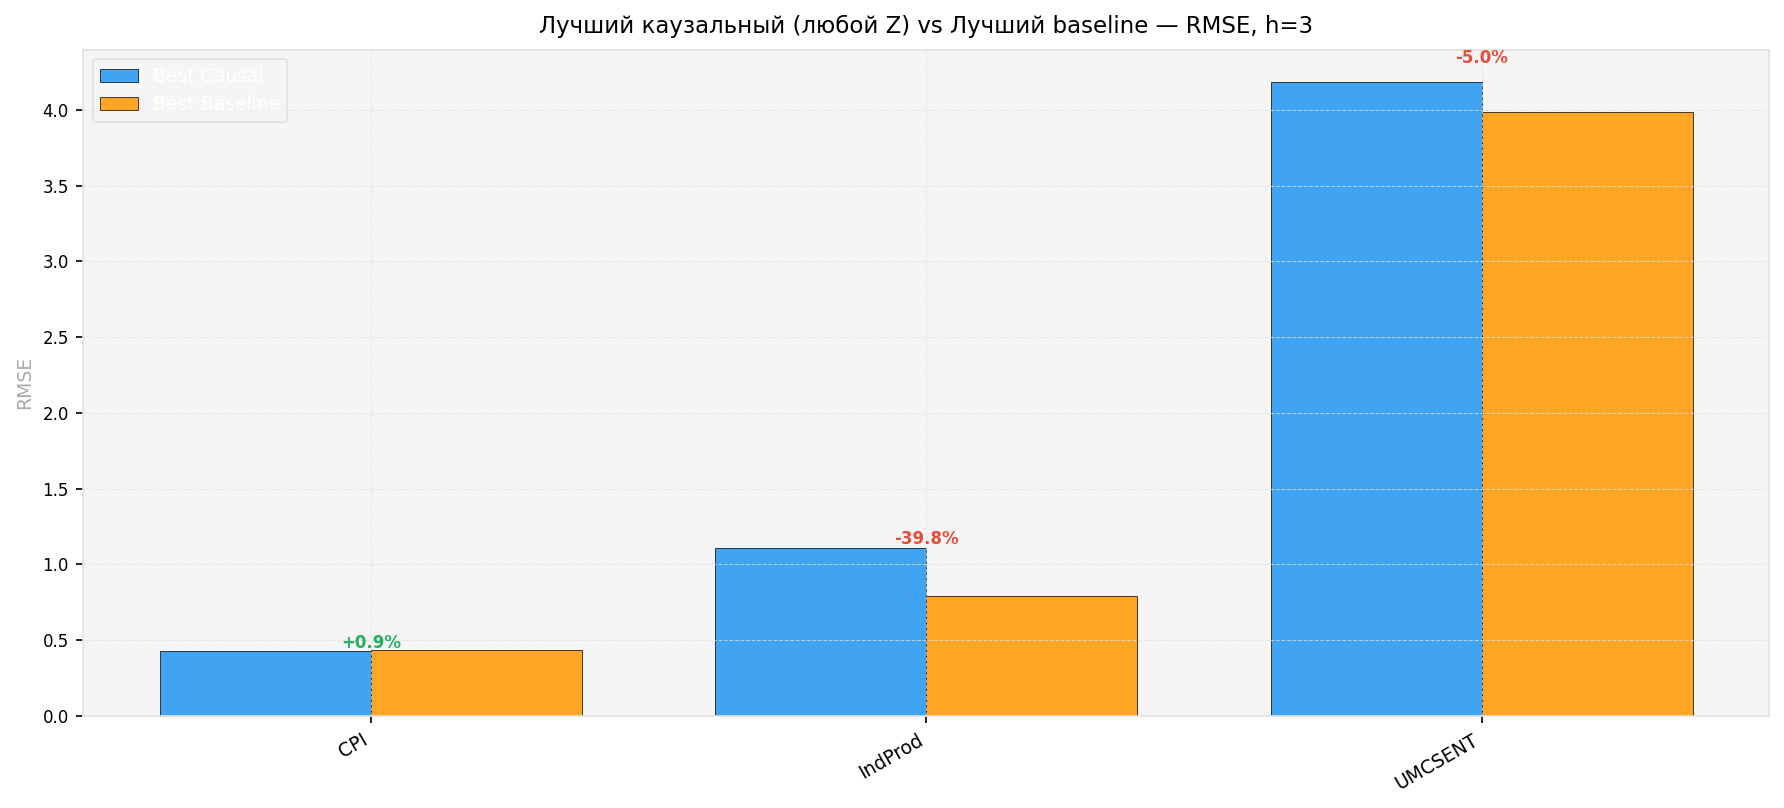


causal_vs_baseline_RMSE_h5.png


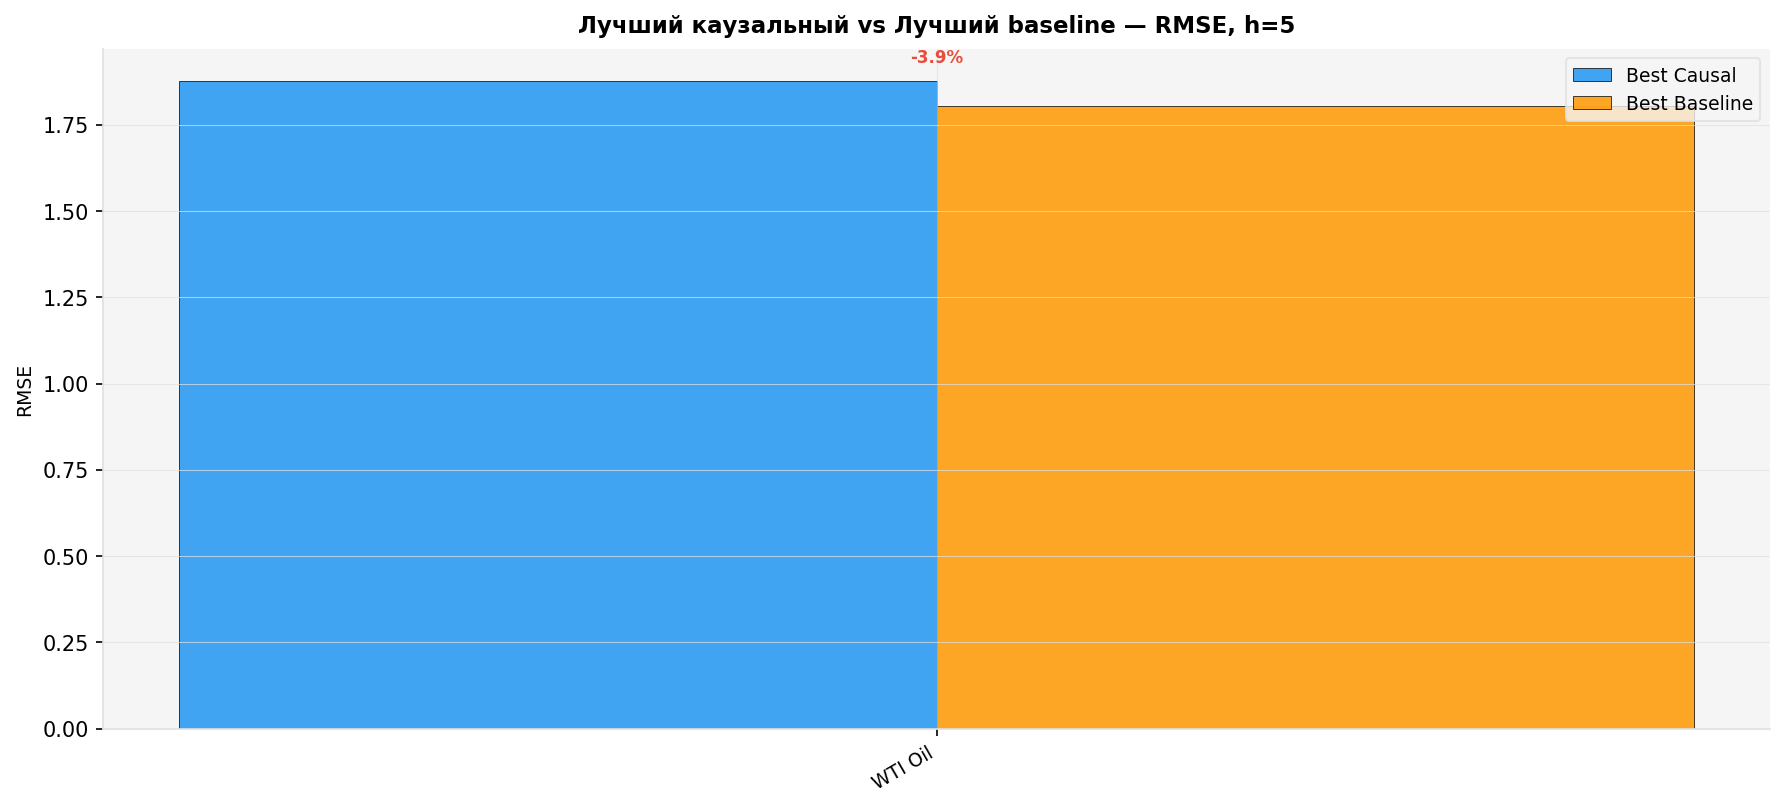


causal_vs_baseline_RMSE_h6.png


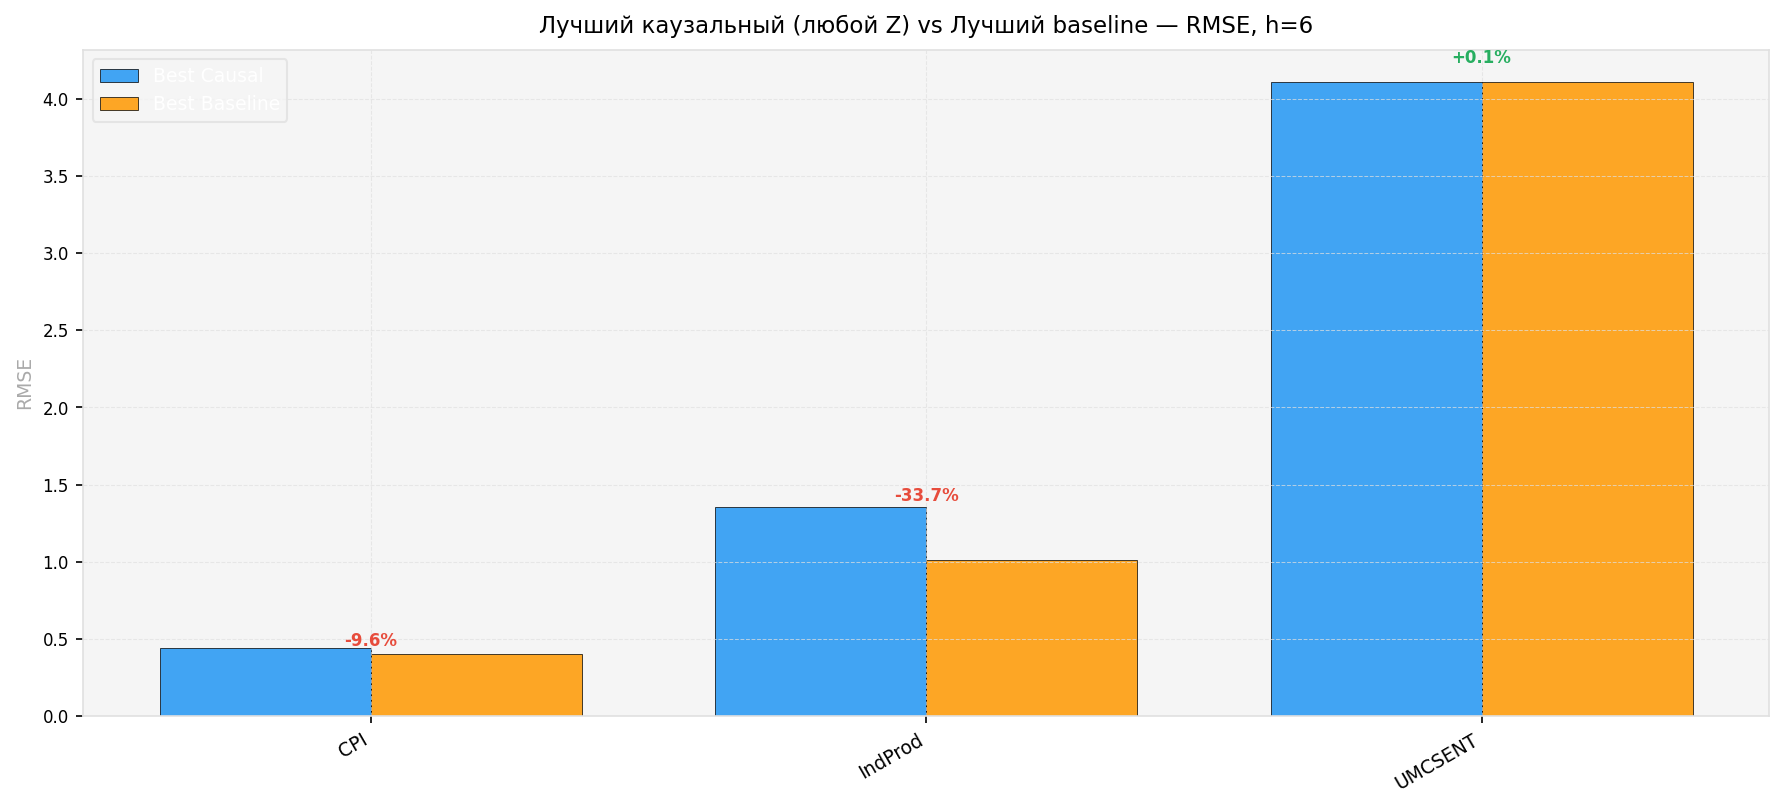


dag_divergence_RMSE.png


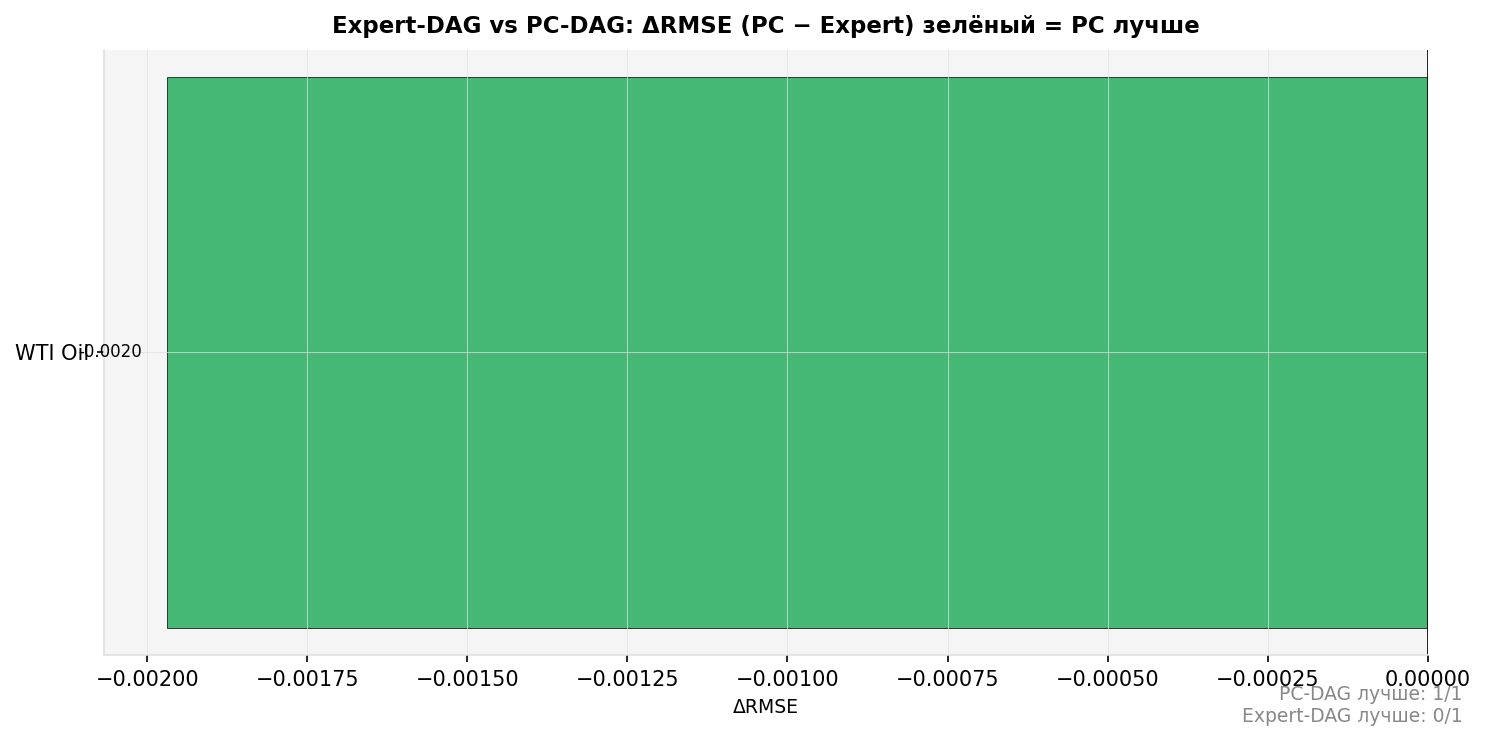


heatmap_RMSE_h1.png


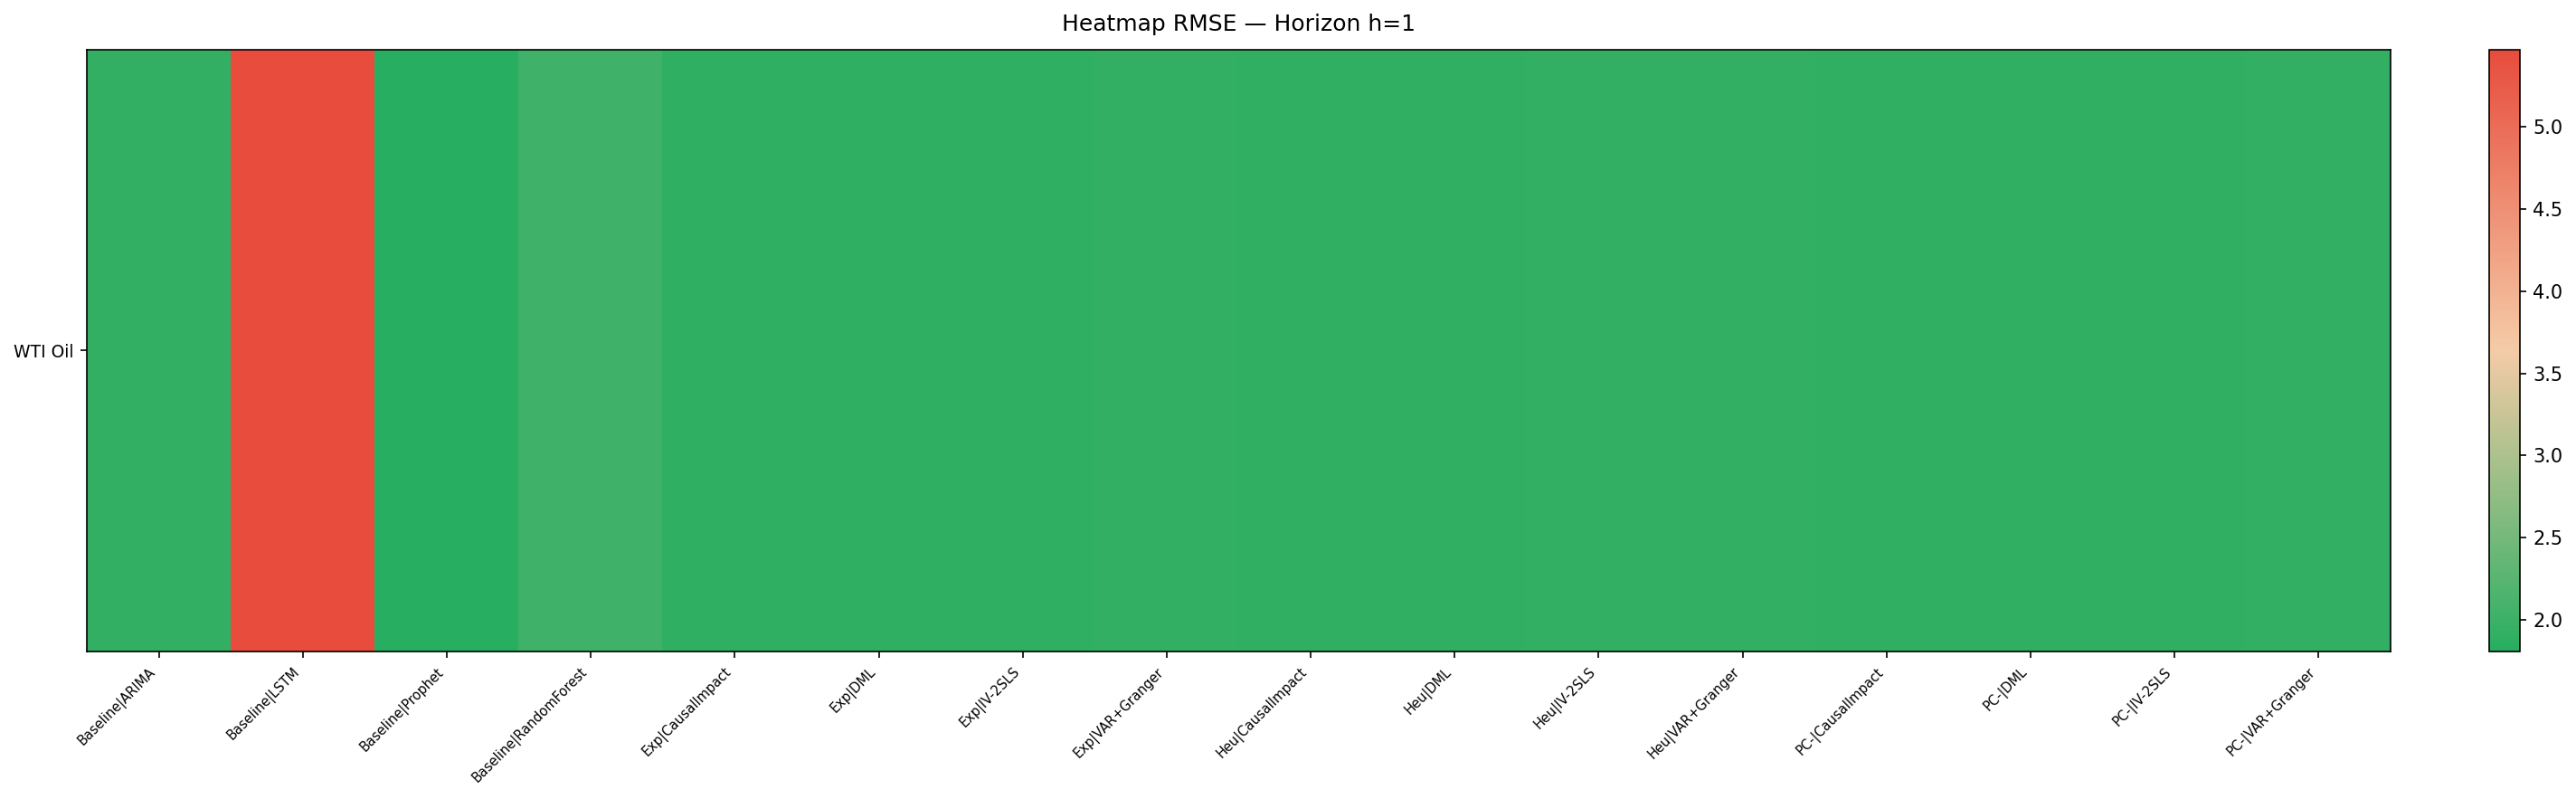


heatmap_RMSE_h21.png


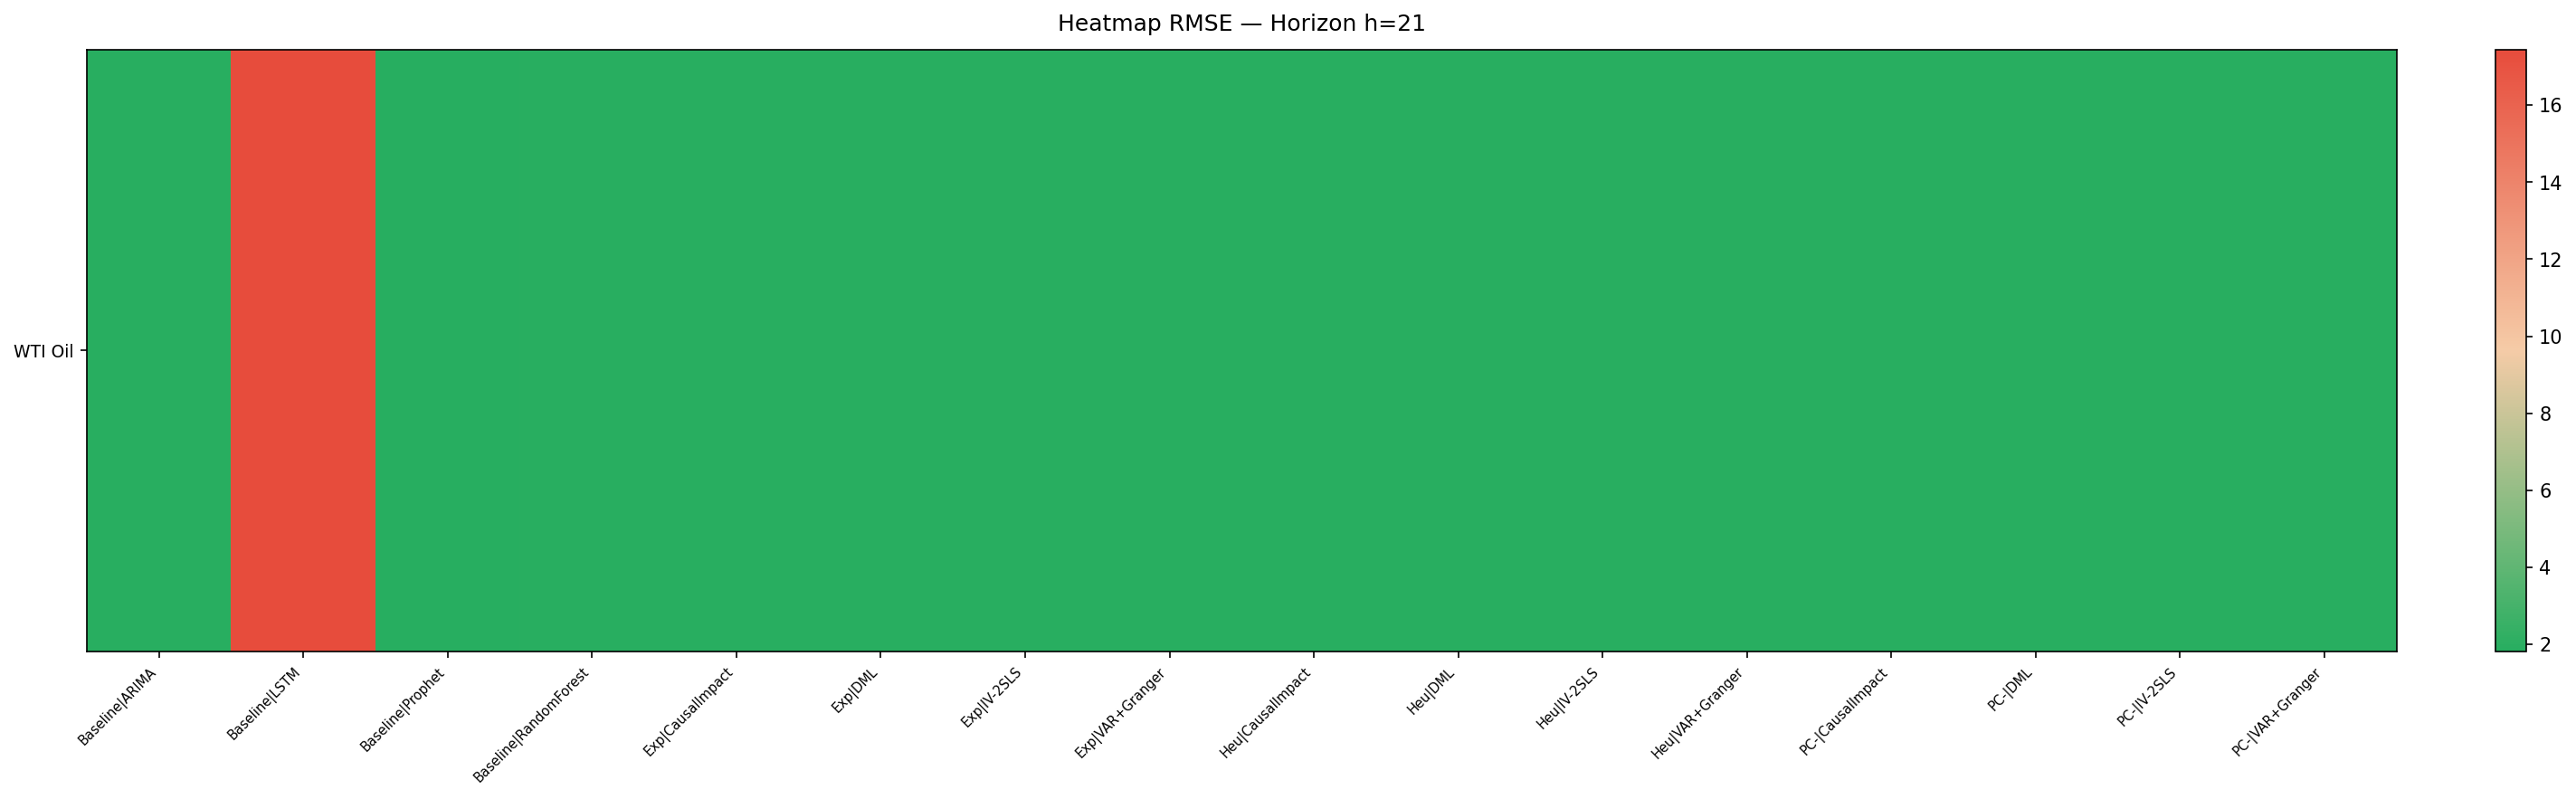


heatmap_RMSE_h3.png


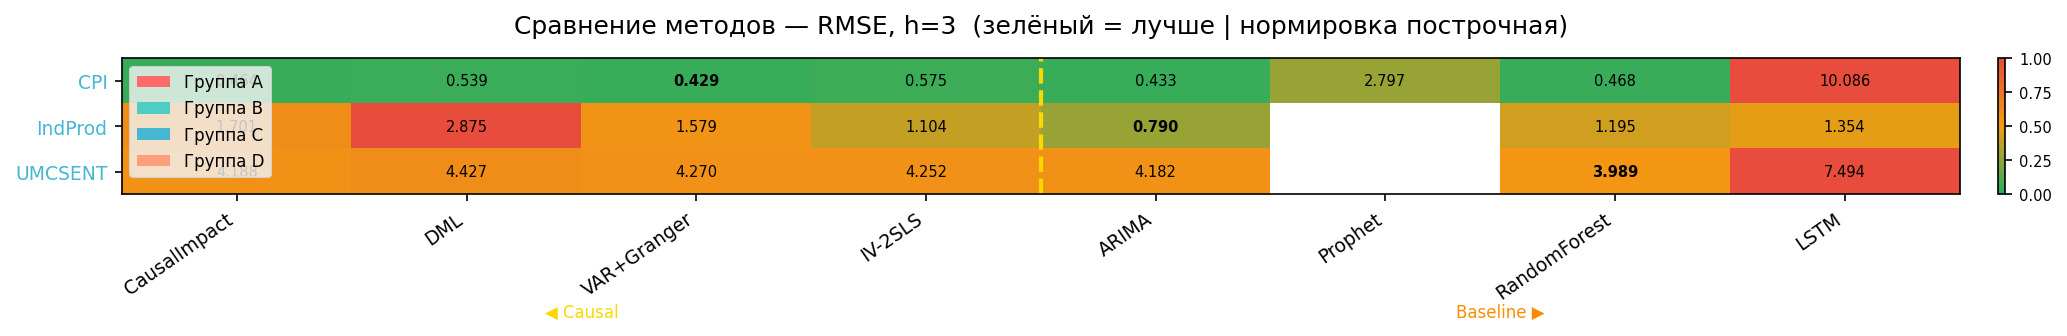


heatmap_RMSE_h5.png


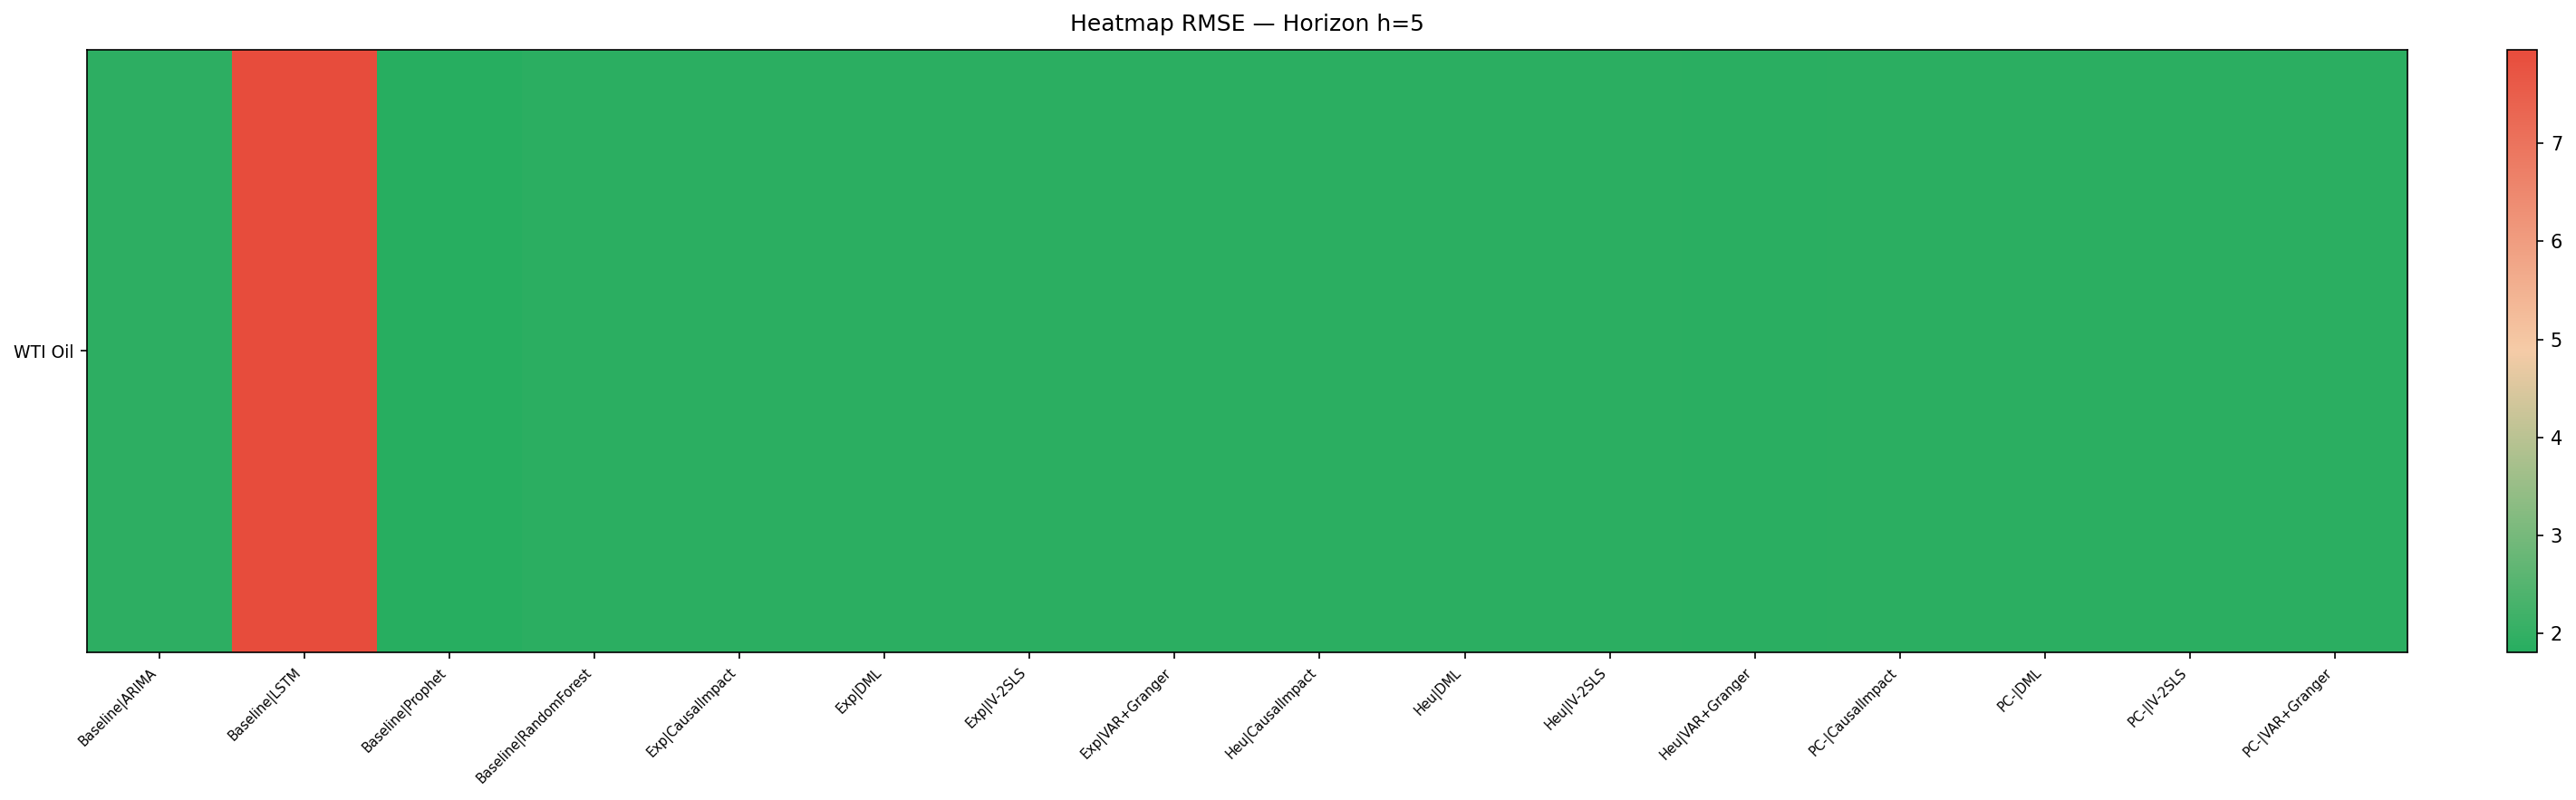


heatmap_RMSE_h6.png


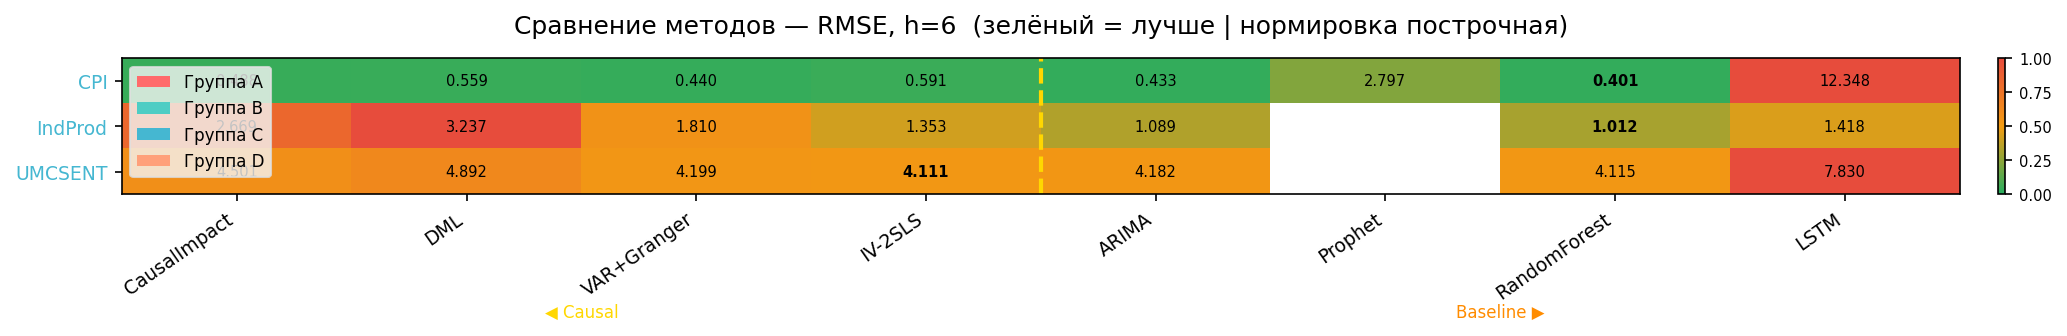


horizon_progression_RMSE.png


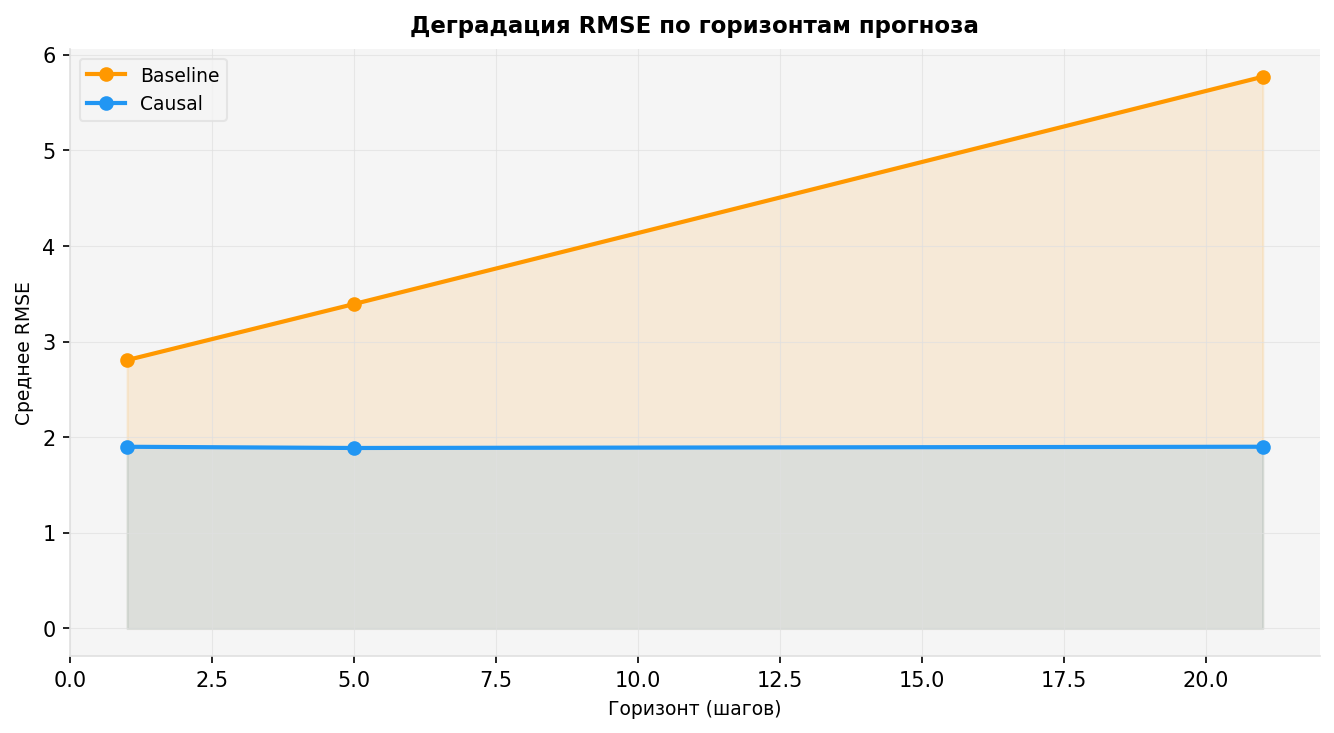

In [85]:
# Показываем сохранённые графики в ноутбуке
from IPython.display import Image, display as ipy_display
import os

for fig_path in sorted(FIGURES_DIR.glob("*.png")):
    print(f"\n{fig_path.name}")
    ipy_display(Image(filename=str(fig_path), width=900))

In [ ]:
# Список всех выходных файлов
print("\n📁 Результаты:")
for p in sorted(RESULTS_DIR.glob("*")):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:<40} {size_kb:.1f} KB")

print("\n🖼️ Графики:")
for p in sorted(FIGURES_DIR.glob("*.png")):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:<40} {size_kb:.1f} KB")